# Creative Gaming: Uplift Modeling

* Team-lead GitHub userid: rsm-jal167
* Group name: Group 4
* Team member names:
    - Jay Lee
    - Melody Miu
    - Andrew Burda
    - Juan Hernandez Guizar

## Case Study Setup

In [1]:
import pandas as pd
import pyrsm as rsm

In [2]:
## loading the organic cg_rct_stacked - this cg_rct_stackedset must NOT be changed
cg_organic_control = pd.read_parquet("data/cg_organic_control.parquet").reset_index(drop=True)
cg_organic_control.head()

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,TimesLostSpaceship,TimesKilled,TimesCaptain,TimesNavigator,PurchasedCoinPackSmall,PurchasedCoinPackLarge,NumAdsClicked,DaysUser,UserConsole,UserHasOldOS
0,no,7,18,0,124,0,81,0,yes,no,8,0,0,4,no,yes,3,2101,no,no
1,no,10,3,2,60,0,18,479,no,no,10,7,0,0,yes,no,7,1644,yes,no
2,no,2,1,0,0,0,0,0,no,no,0,0,0,2,no,no,8,3197,yes,yes
3,no,2,11,1,125,0,73,217,no,no,0,0,0,0,yes,no,6,913,no,no
4,no,8,15,0,0,0,6,51,yes,no,0,0,2,1,yes,no,21,2009,yes,no


In [3]:
rsm.md("cg_rct_stacked/cg_organic_control_description.md")

cg_rct_stacked/cg_organic_control_description.md

In [4]:
## loading the treatment cg_rct_stacked - this cg_rct_stackedset must NOT be changed
cg_ad_treatment = pd.read_parquet("data/cg_ad_treatment.parquet").reset_index(drop=True)
cg_ad_treatment.head()

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,TimesKilled,TimesCaptain,TimesNavigator,PurchasedCoinPackSmall,PurchasedCoinPackLarge,NumAdsClicked,DaysUser,UserConsole,UserHasOldOS,rnd_30k
0,no,6,16,0,0,0,0,0,yes,no,...,0,0,0,no,no,11,1827,no,no,0
1,no,2,8,0,0,0,5,4,no,no,...,0,8,0,yes,no,3,1889,no,yes,1
2,no,6,1,0,0,0,0,0,no,no,...,0,0,0,no,yes,2,1948,yes,no,0
3,yes,7,16,0,102,1,0,194,no,no,...,0,0,0,yes,yes,21,3409,yes,yes,0
4,no,10,1,1,233,0,23,0,no,no,...,0,5,0,no,yes,4,2922,yes,no,0


In [5]:
# rsm.md("cg_rct_stacked/cg_ad_treatment_description.md")

In [6]:
## loading the treatment cg_rct_stacked - this cg_rct_stackedset must NOT be changed
cg_ad_random = pd.read_parquet("data/cg_ad_random.parquet").reset_index(drop=True)
cg_ad_random.head()

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,TimesLostSpaceship,TimesKilled,TimesCaptain,TimesNavigator,PurchasedCoinPackSmall,PurchasedCoinPackLarge,NumAdsClicked,DaysUser,UserConsole,UserHasOldOS
0,no,2,8,0,0,0,5,4,no,no,0,0,8,0,yes,no,3,1889,no,yes
1,no,5,15,0,179,0,50,362,yes,no,22,0,4,4,no,no,2,1308,yes,no
2,no,7,7,0,267,0,64,0,no,no,5,0,0,0,no,yes,1,3562,yes,no
3,no,4,4,0,36,0,0,0,no,no,0,0,0,0,no,no,2,2922,yes,no
4,no,8,17,0,222,10,63,20,yes,no,10,0,9,6,yes,no,4,2192,yes,no


In [7]:
# rsm.md("cg_rct_stacked/cg_ad_random_description.md")

In [8]:
# load a custom python module
#from utils.functions import example

#example()

## Questions

### Part 1 Uplift Modeling Using Machine Learning

#### a. Add a variable “ad” to cg_ad_random and set its value to 1 for all rows
#### b. Add a variable “ad” to cg_organic_control and set its value to 0 for all rows

In [9]:
cg_ad_random["ad"] = 1
cg_organic_control["ad"] = 0

#### c. Create a stacked cg_rct_stackedset for the uplift analysis by combining cg_organic_control (Group 1) and cg_ad_random (Group 2). Use cg_rct_stacked as the name for the stacked cg_rct_stackedset.

In [10]:
cg_rct_stacked = pd.concat([cg_ad_random, cg_organic_control])
cg_rct_stacked.shape[0]

60000

#### d. Create a training variable (70% training and 30% test). Use 1234 as the seed. Use “converted” and “ad” as the blocking variables, in that order. 
#### Hint: Review the code in uplift_demo.ipynb in the assignment repo for an example of how to set this up.

In [11]:
cg_rct_stacked["training"] = rsm.model.make_train(data=cg_rct_stacked, test_size=0.3, strat_var=["converted", "ad"])
cg_rct_stacked["training"] = cg_rct_stacked["training"].astype("int")

cg_rct_stacked.head()

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,TimesCaptain,TimesNavigator,PurchasedCoinPackSmall,PurchasedCoinPackLarge,NumAdsClicked,DaysUser,UserConsole,UserHasOldOS,ad,training
0,no,2,8,0,0,0,5,4,no,no,...,8,0,yes,no,3,1889,no,yes,1,0
1,no,5,15,0,179,0,50,362,yes,no,...,4,4,no,no,2,1308,yes,no,1,1
2,no,7,7,0,267,0,64,0,no,no,...,0,0,no,yes,1,3562,yes,no,1,0
3,no,4,4,0,36,0,0,0,no,no,...,0,0,no,no,2,2922,yes,no,1,1
4,no,8,17,0,222,10,63,20,yes,no,...,9,6,yes,no,4,2192,yes,no,1,1


In [12]:
cg_rct_stacked.training.value_counts(normalize=True)

training
1    0.7
0    0.3
Name: proportion, dtype: float64

#### e. Check if the probability of yes/no is similar across the training and test sets for ad == 0 and ad == 1.

In [13]:
# Checking if the distribution of conversion rates (yes/no) is similar 
# across training (1) and test (0) sets for both treatment (ad = 1) 
# and control (ad = 0) groups. This ensures that the stratified split 
# preserved the balance between groups.
pd.crosstab(cg_rct_stacked.converted, [cg_rct_stacked.ad, cg_rct_stacked.training], normalize="columns").round(2)

ad            0           1      
training      0     1     0     1
converted                        
yes        0.06  0.06  0.13  0.13
no         0.94  0.94  0.87  0.87

In [14]:
# Verifying that the training (1) and test (0) sets contain an equal 
# distribution of treatment (ad = 1) and control (ad = 0) groups. 
# This ensures the cg_rct_stacked split was balanced and representative.
pd.crosstab(cg_rct_stacked.ad, cg_rct_stacked.training)

training,0,1
ad,,
0,9000,21000
1,9000,21000


In [15]:
evar = cg_rct_stacked.columns.tolist()
evar = evar[evar.index("GameLevel") : evar.index("UserHasOldOS") + 1]
evar

['GameLevel',
 'NumGameDays',
 'NumGameDays4Plus',
 'NumInGameMessagesSent',
 'NumSpaceHeroBadges',
 'NumFriendRequestIgnored',
 'NumFriends',
 'AcquiredSpaceship',
 'AcquiredIonWeapon',
 'TimesLostSpaceship',
 'TimesKilled',
 'TimesCaptain',
 'TimesNavigator',
 'PurchasedCoinPackSmall',
 'PurchasedCoinPackLarge',
 'NumAdsClicked',
 'DaysUser',
 'UserConsole',
 'UserHasOldOS']

#### 2. Train an uplift model using Logistic Regression. Add predictions using the treatment and control models, i.e., pred_control and pred_treatment, to cg_rct_stacked (or add them to a separate cg_rct_stackedFrame called pred_store) and calculate the uplift score.

In [16]:
clf_random = rsm.model.logistic(
    data={"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 1")},
    rvar="converted",
    lev="yes",
    evar=evar,
)
clf_random.summary()


Logistic regression (GLM)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Null hyp.: There is no effect of x on converted
Alt. hyp.: There is an effect of x on converted

                                OR     OR%  coefficient  std.error  z.value p.value     
Intercept                    0.030  -97.0%        -3.52      0.122  -28.987  < .001  ***
AcquiredSpaceship[yes]       1.088    8.8%         0.08      0.049    1.732   0.083    .
AcquiredIonWeapon[yes]       0.917   -8.3%        -0.09      0.164   -0.533   0.594     
PurchasedCoinPackSmall[yes]  1.045    4.5%         0.04      0.046    0.960   

In [17]:
clf_control = rsm.model.logistic(
    data={"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 0")},
    rvar="converted",
    lev="yes",
    evar=evar,
)
clf_control.summary()

Logistic regression (GLM)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Null hyp.: There is no effect of x on converted
Alt. hyp.: There is an effect of x on converted

                                OR     OR%  coefficient  std.error  z.value p.value     
Intercept                    0.006  -99.4%        -5.18      0.193  -26.809  < .001  ***
AcquiredSpaceship[yes]       1.594   59.4%         0.47      0.072    6.472  < .001  ***
AcquiredIonWeapon[yes]       0.860  -14.0%        -0.15      0.267   -0.566   0.571     
PurchasedCoinPackSmall[yes]  1.029    2.9%         0.03      0.069    0.415   

In [18]:
cg_rct_stacked["pred_random"] = clf_random.predict(cg_rct_stacked)["prediction"]
cg_rct_stacked["pred_control"] = clf_control.predict(cg_rct_stacked)["prediction"]

In [19]:
cg_rct_stacked["uplift_score"] = cg_rct_stacked.pred_random - cg_rct_stacked.pred_control

In [20]:
cg_rct_stacked.head()

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,PurchasedCoinPackLarge,NumAdsClicked,DaysUser,UserConsole,UserHasOldOS,ad,training,pred_random,pred_control,uplift_score
0,no,2,8,0,0,0,5,4,no,no,...,no,3,1889,no,yes,1,0,0.039859,0.009893,0.029967
1,no,5,15,0,179,0,50,362,yes,no,...,no,2,1308,yes,no,1,1,0.091311,0.011963,0.079347
2,no,7,7,0,267,0,64,0,no,no,...,yes,1,3562,yes,no,1,0,0.052567,0.018791,0.033777
3,no,4,4,0,36,0,0,0,no,no,...,no,2,2922,yes,no,1,1,0.040961,0.017497,0.023465
4,no,8,17,0,222,10,63,20,yes,no,...,no,4,2192,yes,no,1,1,0.106258,0.607562,-0.501304


#### 3. Calculate the Uplift (%) and Incremental Uplift (%) for the uplift model (use 20 instead of the standard 10 bins) and plot performance metrics. Interpret the plots.

##### Hint: Use functions from the pyrsm package to generate the uplift table (uplift_tab), the incremental uplift (inc_uplift_plot), and the uplift plot (uplift_plot).

In [21]:
# Filtering, selecting, and sorting the cg_rct_stackedset to analyze uplift on test cg_rct_stacked
(
    cg_rct_stacked[["converted", "ad", "training", "pred_random", "pred_control", "uplift_score"]]
    .query("training == 0")
    .sort_values("uplift_score", ascending=False)
)

,converted,ad,training,pred_random,pred_control,uplift_score
17708,no,0,0,0.980868,0.021444,0.959424
16867,no,0,0,0.700271,0.008880,0.691391
25710,no,1,0,0.796051,0.128002,0.668049
27668,no,0,0,0.763933,0.109287,0.654647
207,no,1,0,0.701397,0.068474,0.632923
...,...,...,...,...,...,...
27308,no,1,0,0.125744,0.910955,-0.785211
17019,no,1,0,0.114816,0.901620,-0.786804
3181,no,0,0,0.101766,0.891800,-0.790034
12502,no,1,0,0.163282,0.963696,-0.800414


In [22]:
train_set = cg_rct_stacked[cg_rct_stacked["training"] == True] # Contains only training cg_rct_stacked (training == 1)
test_set = cg_rct_stacked[cg_rct_stacked["training"] == False] # Contains only test cg_rct_stacked (training == 0)

In [23]:
train_ad0 = train_set[train_set['ad'] == 0]['converted'].value_counts(normalize=True)
test_ad0 = test_set[test_set['ad'] == 0]['converted'].value_counts(normalize=True)

# Count yes/no for ad == 1 in train and test
train_ad1 = train_set[train_set['ad'] == 1]['converted'].value_counts(normalize=True)
test_ad1 = test_set[test_set['ad'] == 1]['converted'].value_counts(normalize=True)

# Print results
print("Train Ad == 0 (no ad):", train_ad0.to_dict())
print("Test Ad == 0 (no ad):", test_ad0.to_dict())

print("Train Ad == 1 (ad received):", train_ad1.to_dict())
print("Test Ad == 1 (ad received):", test_ad1.to_dict())

Train Ad == 0 (no ad): {'no': 0.9431428571428572, 'yes': 0.056857142857142856}
Test Ad == 0 (no ad): {'no': 0.9431111111111111, 'yes': 0.05688888888888889}
Train Ad == 1 (ad received): {'no': 0.8695714285714286, 'yes': 0.13042857142857142}
Test Ad == 1 (ad received): {'no': 0.8695555555555555, 'yes': 0.13044444444444445}


In [24]:
# Compute uplift table by binning test cg_rct_stacked into 20 quantiles based on uplift scores
tab = rsm.uplift_tab(
    cg_rct_stacked.query("training == 0"),    # Only use test cg_rct_stacked for evaluation
    "converted",                    # Target variable indicating conversion
    "yes",                          # Positive outcome level for conversion
    "uplift_score",                 # Predicted uplift score (model output)
    "ad",                           # Treatment indicator (1 = ad shown, 0 = no ad)
    1,
    qnt=20                          # Divide the cg_rct_stacked into 20 bins instead of the default 10
)

# Display the uplift table
tab

,pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
0,uplift_score,1,0.05,197,450,70,634,147.315457,1.636838,0.327368
1,uplift_score,2,0.10,309,900,99,1182,233.619289,2.595770,0.195969
2,uplift_score,3,0.15,428,1350,125,1686,327.911032,3.643456,0.212857
3,uplift_score,4,0.20,528,1800,152,2175,402.206897,4.468966,0.167007
4,uplift_score,5,0.25,594,2250,166,2684,454.842027,5.053800,0.119162
5,uplift_score,6,0.30,642,2700,183,3150,485.142857,5.390476,0.070186
6,uplift_score,7,0.35,681,3150,195,3658,513.080372,5.700893,0.063045
7,uplift_score,8,0.40,719,3600,200,4127,544.539133,6.050435,0.073783
8,uplift_score,9,0.45,756,4050,210,4577,570.179594,6.335329,0.060000
9,uplift_score,10,0.50,791,4500,231,5076,586.212766,6.513475,0.035694


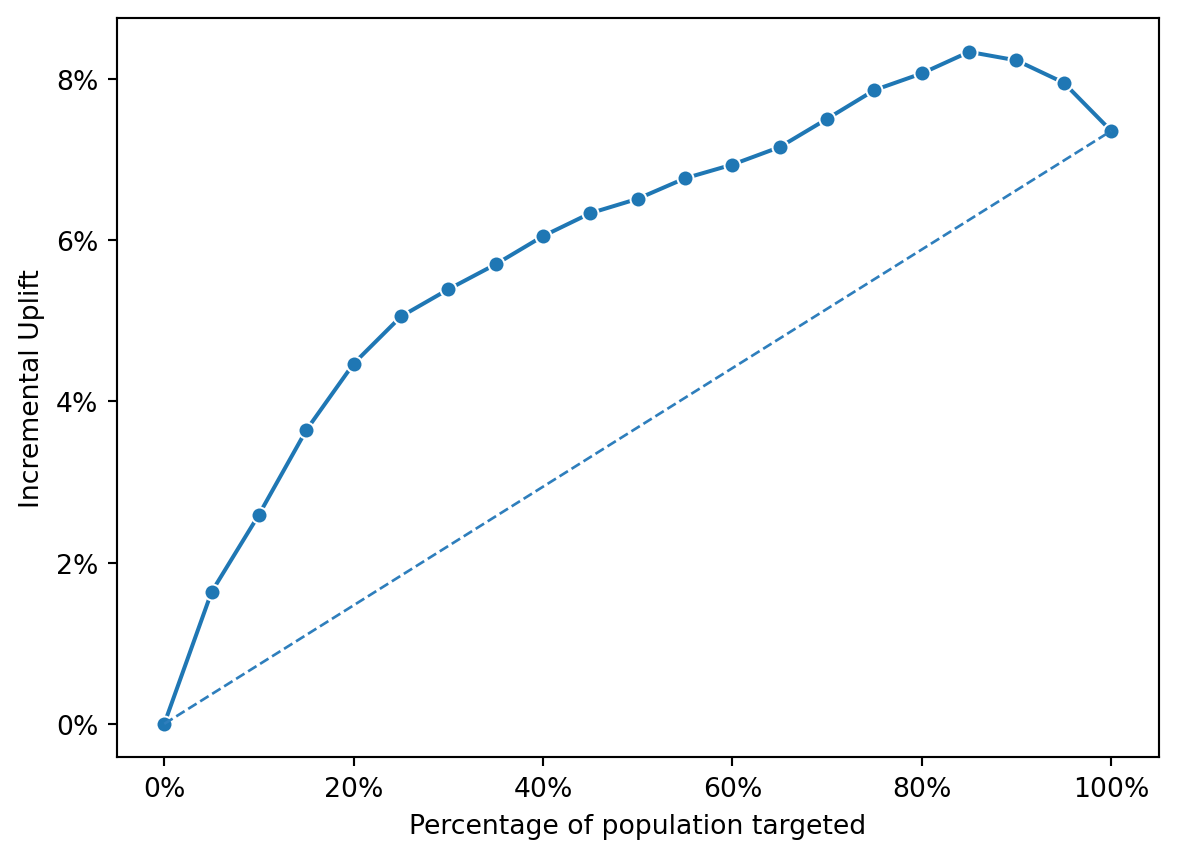

In [25]:
fig = rsm.inc_uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "uplift_score", "ad", 1, qnt = 20)

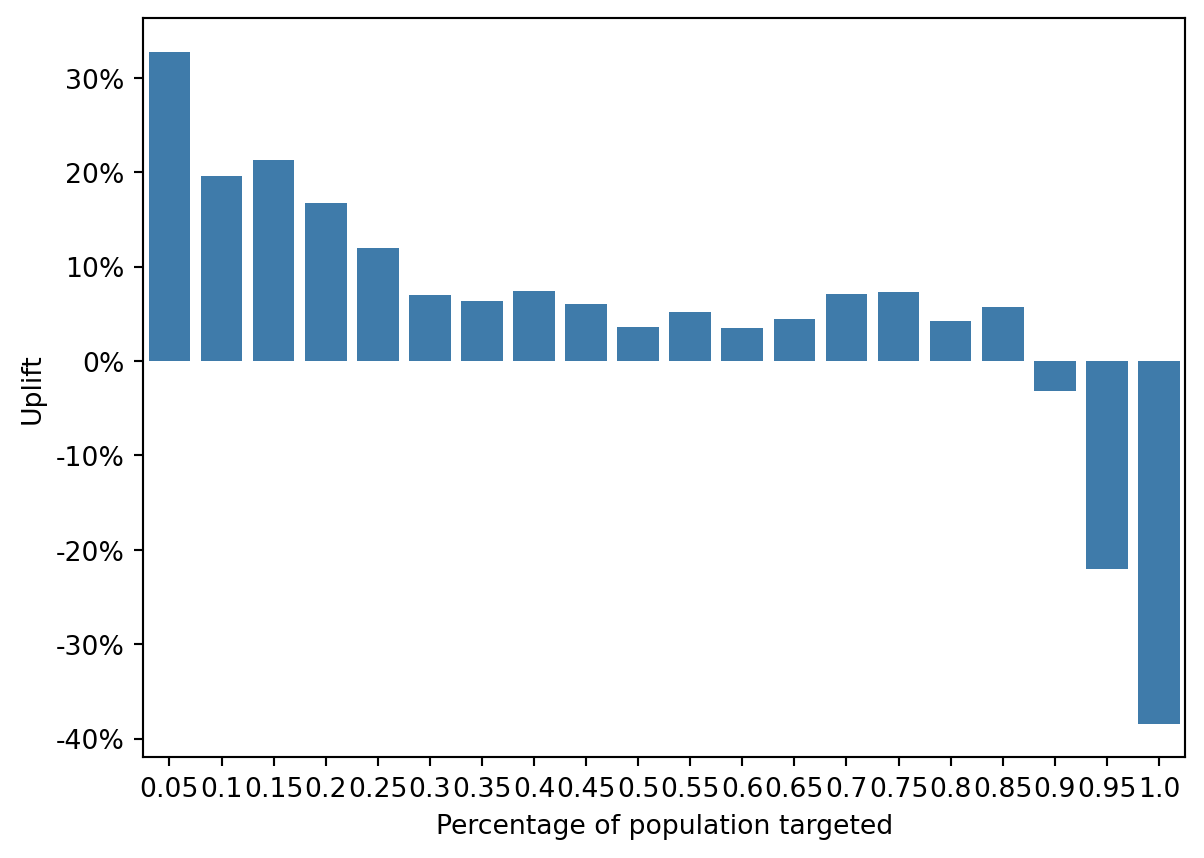

In [26]:
fig = rsm.uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "uplift_score", "ad", 1, qnt = 20)

📊 Interpretation of the Uplift Model Performance

1️⃣ High-Uplift Groups (Left Side of the Graphs)
- **The top 20-30% of users (highest uplift scores) see a significant positive uplift.**
  - These users should be the **primary target audience** for the campaign.

2️⃣ Mid-Uplift Groups (Middle of the Graphs)
- Some bins show **neutral or small uplift**, meaning ads may or may not be effective.
- This segment could be **A/B tested** to improve conversion rates.

3️⃣ Negative-Uplift Groups (Right Side of the Graphs)
- The **lowest 20% of uplift scores show negative uplift**, meaning these users converted **less** when shown the ad.
- Ads may be **ineffective or even harmful** for these users (these are the "Do Not Disturbs" discussed in class).
- **Recommendation:** ❌ **Do not target this group** to avoid wasting marketing budget.

4️⃣ Overall Model Performance
- ✅ The **uplift model effectively separates users** based on their likelihood to convert due to the ad.
- ✅ **High-scoring users benefit** the most from ad exposure.
- ✅ **Low-scoring users should be avoided** to maximize ROI.

#### 4. Using the incremental_resp column from the performance metric table created through the uplift_tab function, and extrapolate the incremental profit you expect to make if you targeted the best 30,000 customers of 120,000 using the uplift model.

##### Hint: For every n-tile, the incremental_resp tells you how many incremental purchases were made when customers up to that n-tile were targeted. To extrapolate to the best 30,000 from 120,000, notice that there are a total of 9,000 customers who got the ad in cg_rct_stacked

In [27]:
# Step 1: Identify how many bins (quantiles) make up the top 30,000 customers
target_customers = 30000
customers_per_bin = 9000 / 20  # Each quantile bin represents 5% of 9000
bins_needed = target_customers / customers_per_bin  # Find how many bins to sum

# Step 2: Sum the incremental responses from the top bins
incremental_purchases = tab["incremental_resp"][:int(bins_needed)].sum()

# Step 3: Extrapolate to the full population of 120,000 customers
scaling_factor = 120000 / 9000  # Scale from 9,000 to 120,000
expected_incremental_purchases = incremental_purchases * scaling_factor

# Print the result
print(f"Expected incremental purchases if targeting top 30,000 customers: {expected_incremental_purchases:.0f}")

Expected incremental purchases if targeting top 30,000 customers: 148274


In [28]:
# Computing Net Profit

# Step 1: Define known values
price_per_purchase = 14.99  # Price of the Zalon campaign
ad_cost_per_customer = 1.50  # Estimated ad cost per targeted customer

# Step 2: Compute total additional revenue
additional_revenue = expected_incremental_purchases * price_per_purchase

# Step 3: Compute total ad costs (assuming 30,000 customers targeted)
total_ad_costs = 30000 * ad_cost_per_customer  # Since we're targeting 30,000 users

# Step 4: Compute net profit
net_profit = additional_revenue - total_ad_costs

# Step 5: Display the results
print(f"💰 Expected additional revenue from targeting top 30,000 customers: ${additional_revenue:,.2f}")
print(f"📉 Total ad costs for targeting 30,000 customers: ${total_ad_costs:,.2f}")
print(f"✅ Expected Net Profit: ${net_profit:,.2f}")

💰 Expected additional revenue from targeting top 30,000 customers: $2,222,630.87
📉 Total ad costs for targeting 30,000 customers: $45,000.00
✅ Expected Net Profit: $2,177,630.87


#### 5. Calculate the Uplift (%) and Incremental Uplift (%) you would get if you used a propensity model (use 20 instead of the standard 10 bins). Compare the performance metrics between the uplift and propensity models and interpret the differences.


##### Hint: Use uplift and incremental uplift plots to compare the uplift and propensity models 

In [29]:
clf_propensity = rsm.model.logistic(
    data={"cg_rct_stacked": cg_rct_stacked.query("training == 1")},
    rvar="converted",
    lev="yes",
    evar=evar,
)
clf_propensity.summary()

Logistic regression (GLM)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Null hyp.: There is no effect of x on converted
Alt. hyp.: There is an effect of x on converted

                                OR     OR%  coefficient  std.error  z.value p.value     
Intercept                    0.018  -98.2%        -4.01      0.099  -40.562  < .001  ***
AcquiredSpaceship[yes]       1.197   19.7%         0.18      0.039    4.614  < .001  ***
AcquiredIonWeapon[yes]       0.969   -3.1%        -0.03      0.133   -0.237   0.813     
PurchasedCoinPackSmall[yes]  1.042    4.2%         0.04      0.037    1.117   

In [30]:
cg_rct_stacked["pred_propensity"] = clf_propensity.predict(cg_rct_stacked)["prediction"]


In [31]:
# Training propensity model
tab_propensity = rsm.uplift_tab(cg_rct_stacked.query("training == 0"), "converted", "yes", "pred_random", "ad", 1, qnt = 20)
tab_propensity

,pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
0,pred_random,1,0.05,204,450,80,603,144.298507,1.603317,0.320663
1,pred_random,2,0.10,326,900,112,1131,236.875332,2.631948,0.210505
2,pred_random,3,0.15,430,1350,159,1605,296.261682,3.291796,0.131955
3,pred_random,4,0.20,525,1800,206,1994,339.042126,3.767135,0.090288
4,pred_random,5,0.25,615,2250,239,2344,385.584471,4.284272,0.105714
5,pred_random,6,0.30,672,2700,285,2807,397.863912,4.420710,0.027315
6,pred_random,7,0.35,726,3150,316,3162,411.199241,4.568880,0.032676
7,pred_random,8,0.40,775,3600,336,3603,439.279767,4.880886,0.063537
8,pred_random,9,0.45,813,4050,361,4044,451.464392,5.016271,0.027755
9,pred_random,10,0.50,838,4500,386,4527,454.302187,5.047802,0.003796


In [32]:
proportion = 30000 / 120000
proportion

0.25

In [33]:
# print incremental_resp for row cum_prop = 0.25
expected_incremental_profit = tab_propensity.query("cum_prop >= @proportion").head(1)["incremental_resp"]
expected_incremental_profit

4    385.584471
Name: incremental_resp, dtype: float64

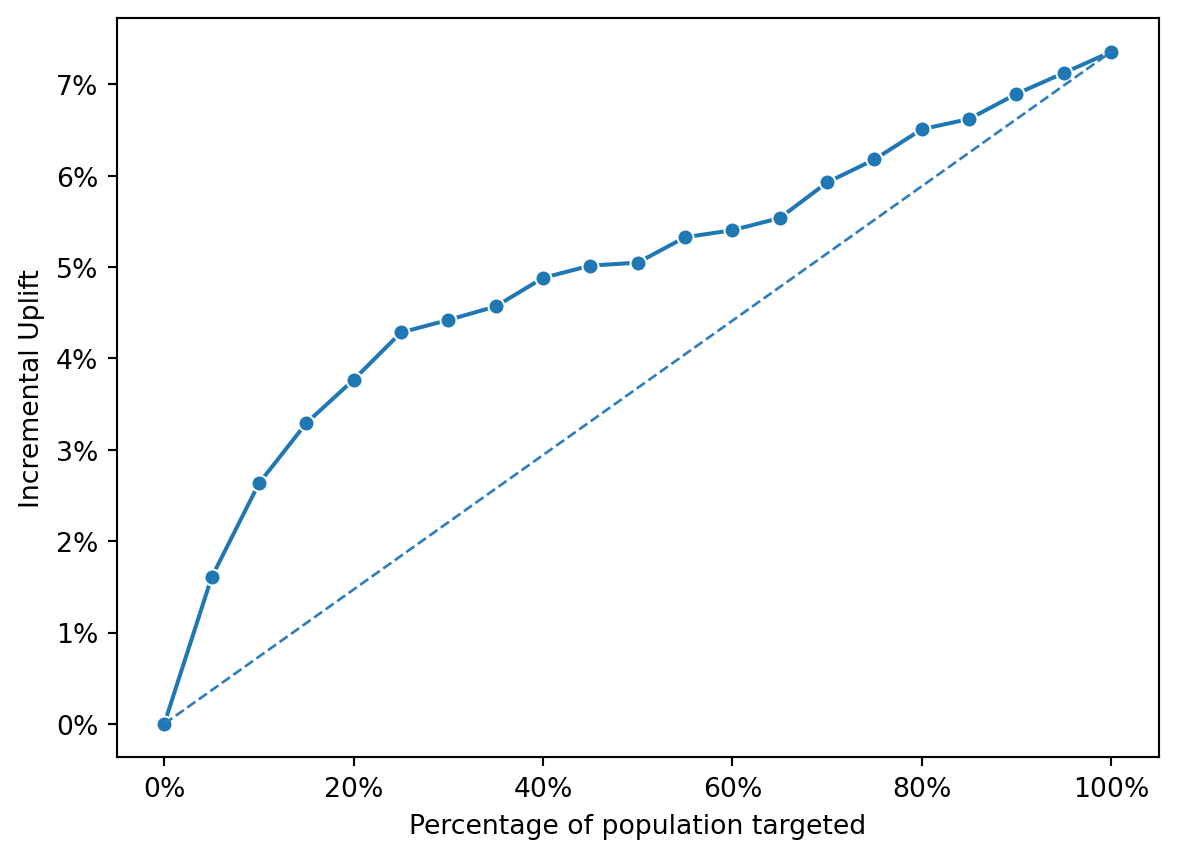

In [34]:
fig = rsm.inc_uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "pred_random", "ad", 1, qnt = 20)

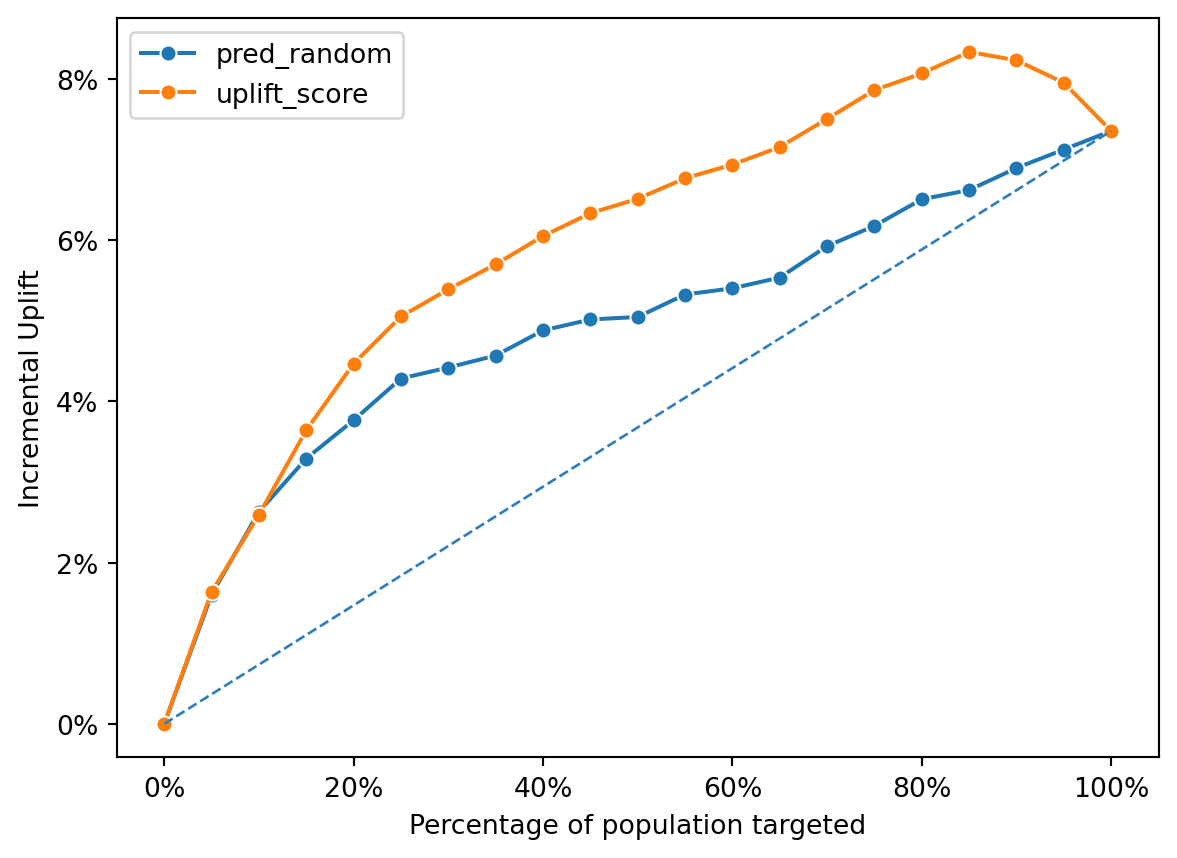

In [35]:
fig = rsm.inc_uplift_plot(
    cg_rct_stacked.query("training == 0"),
    "converted",
    "yes",
    ["pred_random", "uplift_score"],
    "ad",
    1,
    qnt = 20
)

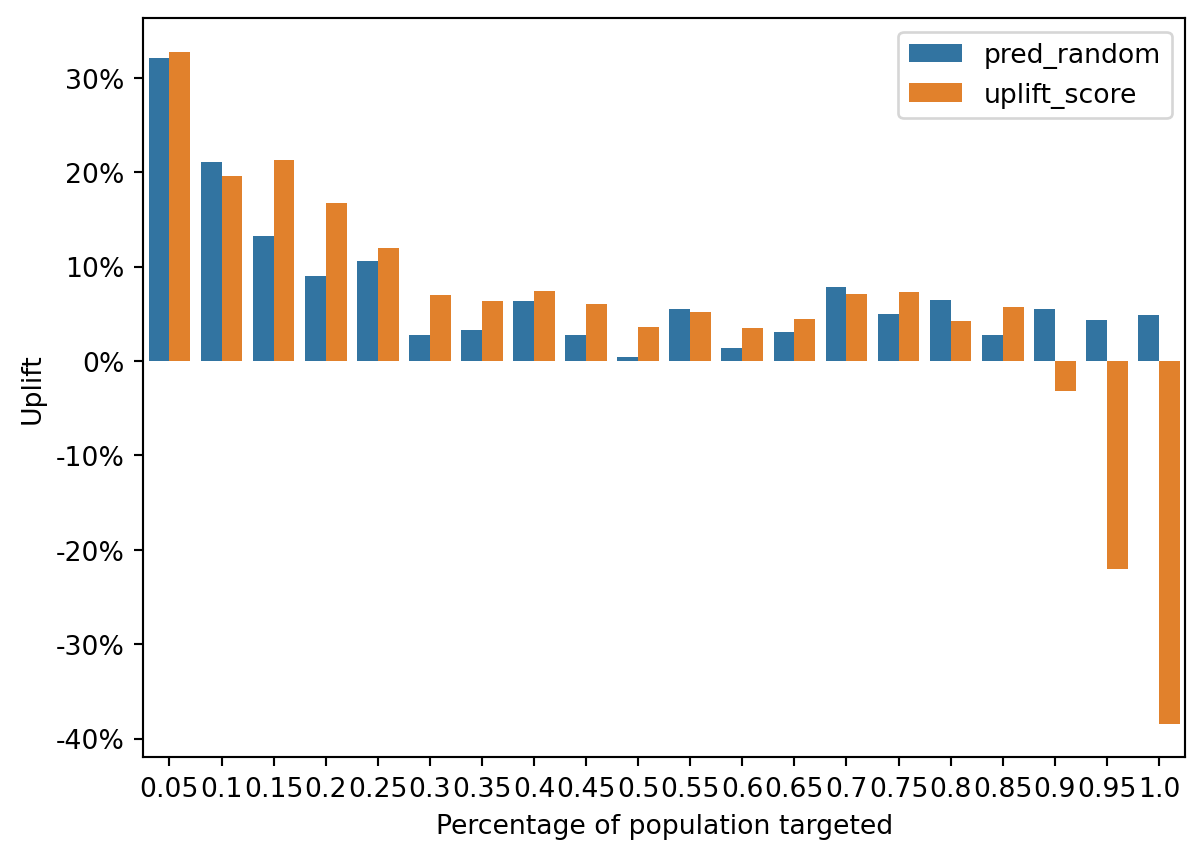

In [36]:
fig = rsm.uplift_plot(
    cg_rct_stacked.query("training == 0"),
    "converted",
    "yes",
    ["pred_random", "uplift_score"],
    "ad",
    1,
    qnt = 20
)

In [37]:
cm = rsm.correlation({"cg_rct_stacked": cg_rct_stacked.loc[cg_rct_stacked.training == 0, "pred_random":"uplift_score"]})
cm.summary()

Correlation
Data     : cg_rct_stacked
Method   : pearson
Cutoff   : 0
Variables: pred_random, pred_control, uplift_score
Null hyp.: variables x and y are not correlated
Alt. hyp.: variables x and y are correlated

Correlation matrix:
             pred_random pred_control
pred_control        0.28             
uplift_score        0.55        -0.65

p.values:
             pred_random pred_control
pred_control         0.0             
uplift_score         0.0          0.0


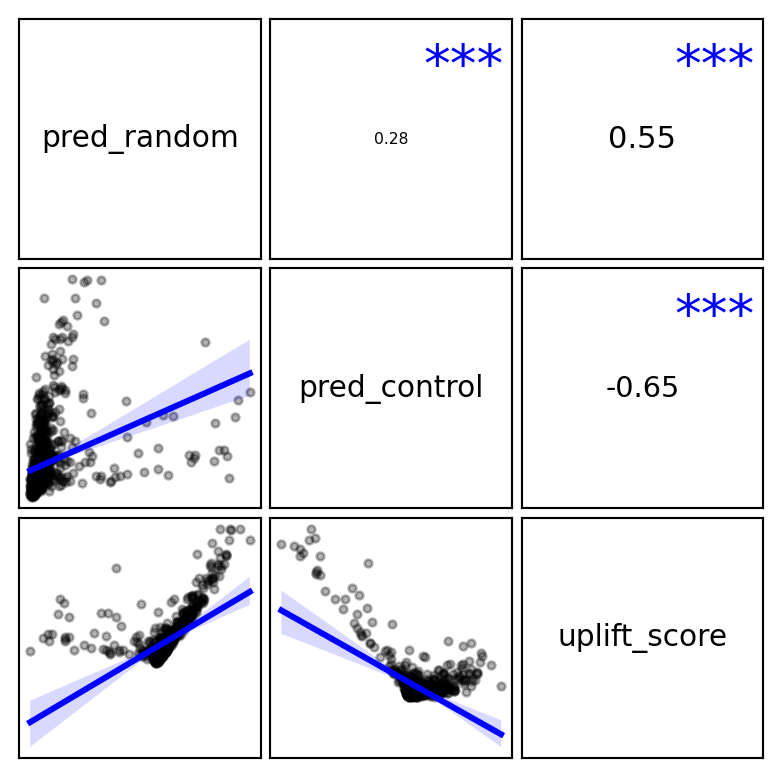

In [38]:
cm.plot()

In [39]:
print(cg_rct_stacked.loc[cg_rct_stacked.training == 0, "pred_random":"uplift_score"].corr().round(2))

              pred_random  pred_control  uplift_score
pred_random          1.00          0.28          0.55
pred_control         0.28          1.00         -0.65
uplift_score         0.55         -0.65          1.00


#### 6. Using the incremental_resp column from the uplift table for the propensity model, extrapolate the incremental profit you would expect to make if you targeted the best 30,000 customers out of of 120,000 using the propensity model. How much more do you expect to make from using an uplift rather than a propensity model?

In [40]:

# Sum the incremental responses from the top bins
incremental_purchases_prop = tab_propensity["incremental_resp"][:int(bins_needed)].sum()

# Extrapolate to the full population of 120,000 customers

expected_incremental_purchases_prop = incremental_purchases_prop * scaling_factor

# Print the result
print(f"Expected incremental purchases if targeting top 30,000 customers: {expected_incremental_purchases_prop:.0f}")

Expected incremental purchases if targeting top 30,000 customers: 122866


In [41]:
# Computing Net Profit


# Compute total additional revenue
additional_revenue_prop = expected_incremental_purchases_prop * price_per_purchase


# Compute net profit
net_profit_prop = additional_revenue_prop - total_ad_costs

# Display the results
print(f"💰 Expected additional revenue from targeting top 30,000 customers: ${additional_revenue_prop:,.2f}")
print(f"📉 Total ad costs for targeting 30,000 customers: ${total_ad_costs:,.2f}")
print(f"✅ Expected Net Profit: ${net_profit_prop:,.2f}")

💰 Expected additional revenue from targeting top 30,000 customers: $1,841,764.77
📉 Total ad costs for targeting 30,000 customers: $45,000.00
✅ Expected Net Profit: $1,796,764.77


#### 7. Repeat steps 2-6 using a Neural Network. Tune the model on at least two hyper parameters

In [42]:
clf_nn = rsm.model.mlp(
    
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 0")},
    hidden_layer_sizes = (5,),
    alpha = .001,
    rvar = "converted",
    lev = "yes",
    evar = evar,

)

clf_nn.summary()

Multi-layer Perceptron (NN)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of weights       : 100
Nr. of observations  : 21,000
Hidden_layer_sizes   : (5,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.869

Raw data             :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFrien

In [43]:
clf_nn2 = rsm.model.mlp(
    
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 0")},
    hidden_layer_sizes = (20,),
    alpha = .2,
    rvar = "converted",
    lev = "yes",
    evar = evar,

)

clf_nn2.summary()

Multi-layer Perceptron (NN)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of weights       : 400
Nr. of observations  : 21,000
Hidden_layer_sizes   : (20,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.2
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.913

Raw data             :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriend

In [44]:
clf_nn3_control = rsm.model.mlp(
    
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 0")},
    hidden_layer_sizes = (40,),
    alpha = .99,
    rvar = "converted",
    lev = "yes",
    evar = evar,

)

clf_nn3_control.summary()

Multi-layer Perceptron (NN)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of weights       : 800
Nr. of observations  : 21,000
Hidden_layer_sizes   : (40,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.99
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.941

Raw data             :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFrien

In [45]:
clf_nn3_random = rsm.model.mlp(
    
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 1")},
    hidden_layer_sizes = (40,),
    alpha = .99,
    rvar = "converted",
    lev = "yes",
    evar = evar,

)

clf_nn3_random.summary()

Multi-layer Perceptron (NN)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of weights       : 800
Nr. of observations  : 21,000
Hidden_layer_sizes   : (40,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.99
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.835

Raw data             :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFrien

In [46]:
clf_nn3_propensity = rsm.model.mlp(
    
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1")},
    hidden_layer_sizes = (40,),
    alpha = .99,
    rvar = "converted",
    lev = "yes",
    evar = evar,

)

clf_nn3_propensity.summary()

Multi-layer Perceptron (NN)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of weights       : 800
Nr. of observations  : 42,000
Hidden_layer_sizes   : (40,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.99
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.82

Raw data             :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriend

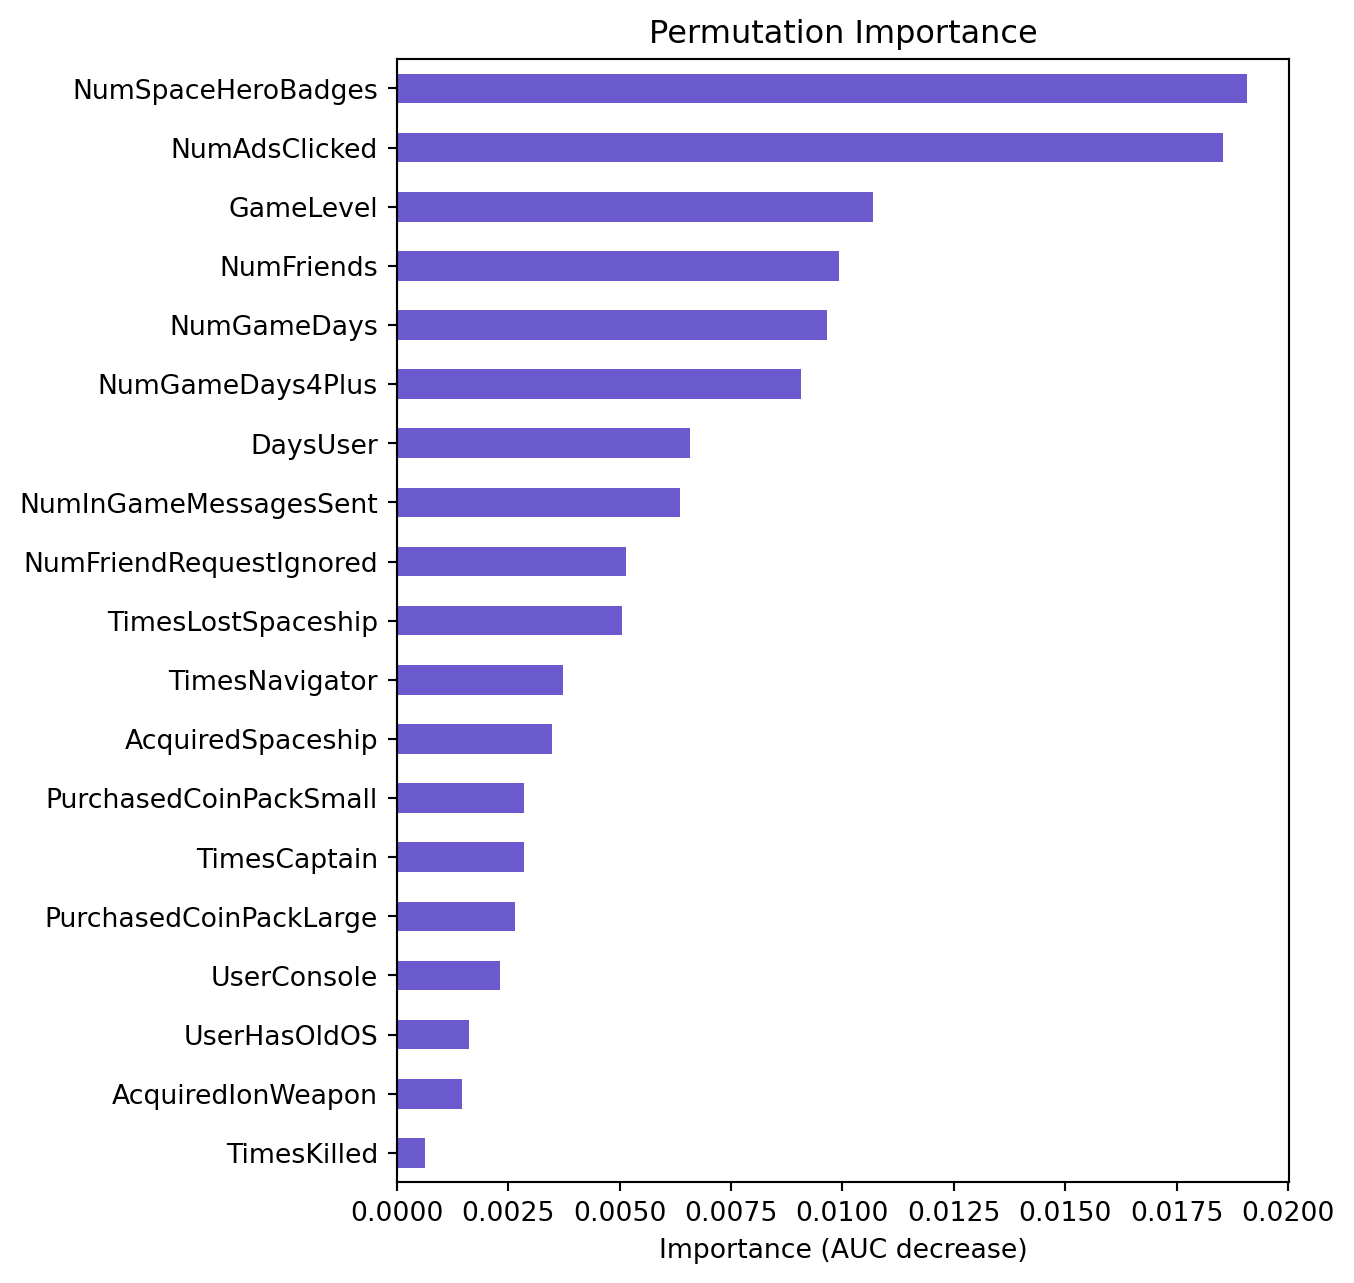

In [47]:
clf_nn3_propensity.plot("vimp")

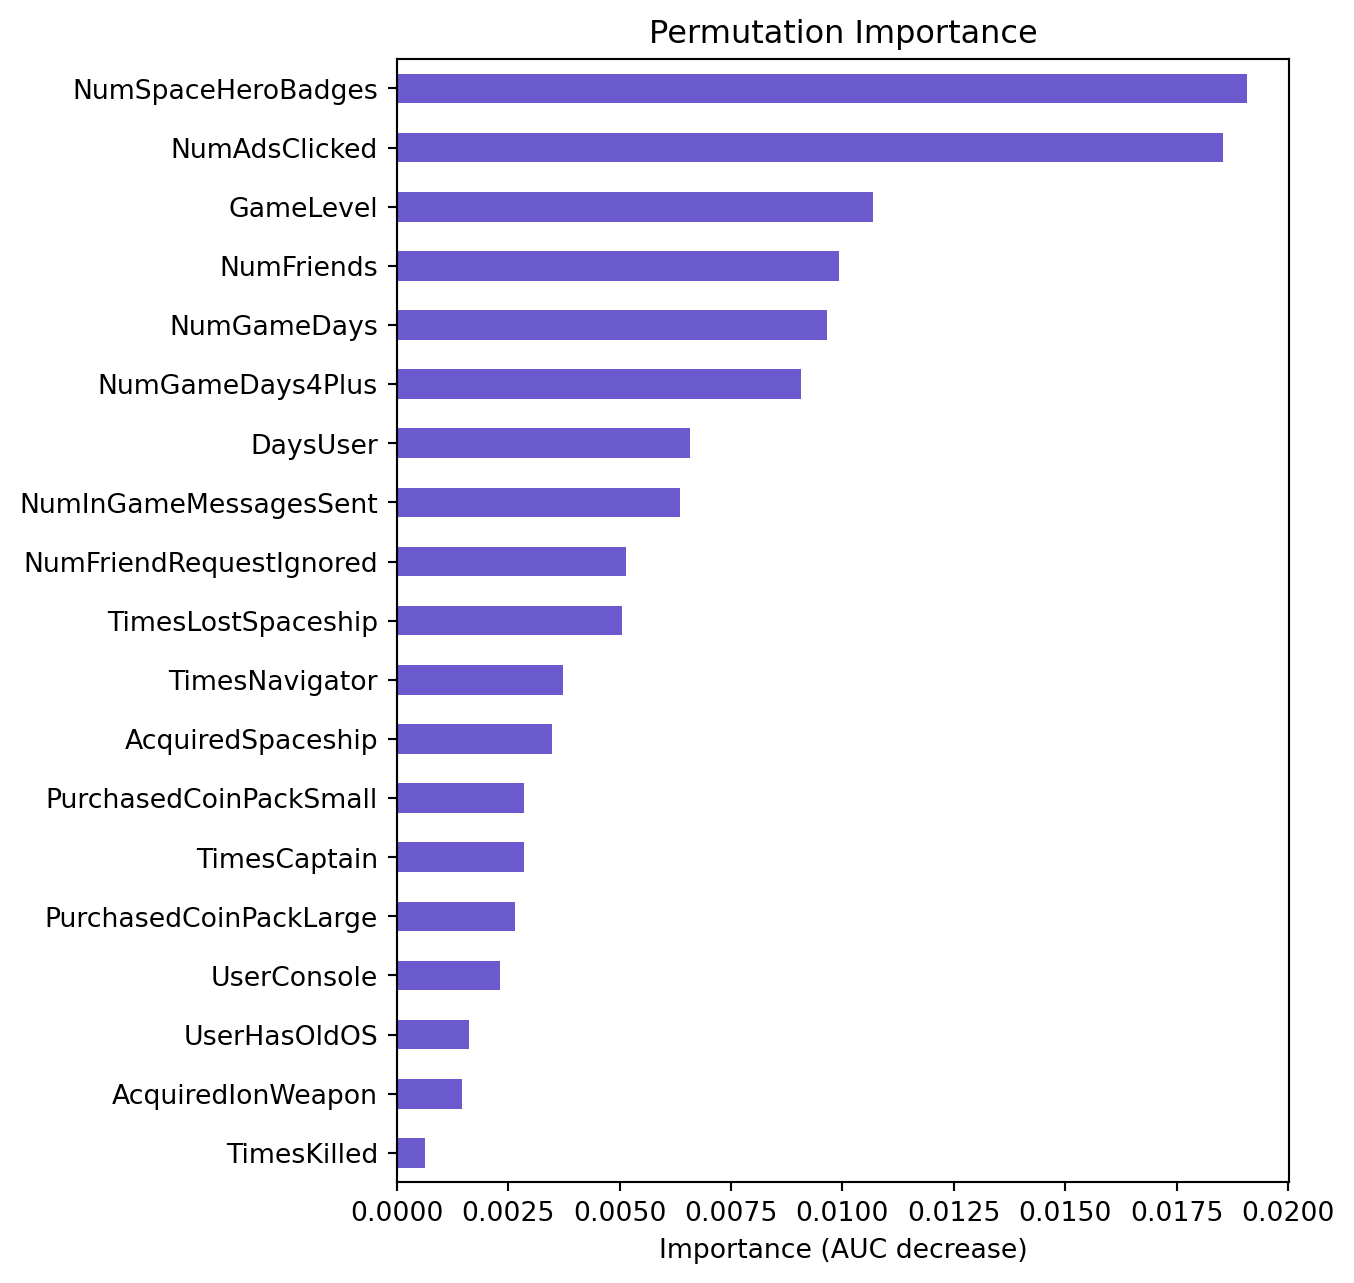

In [48]:
clf_nn3_propensity.plot("vimp")

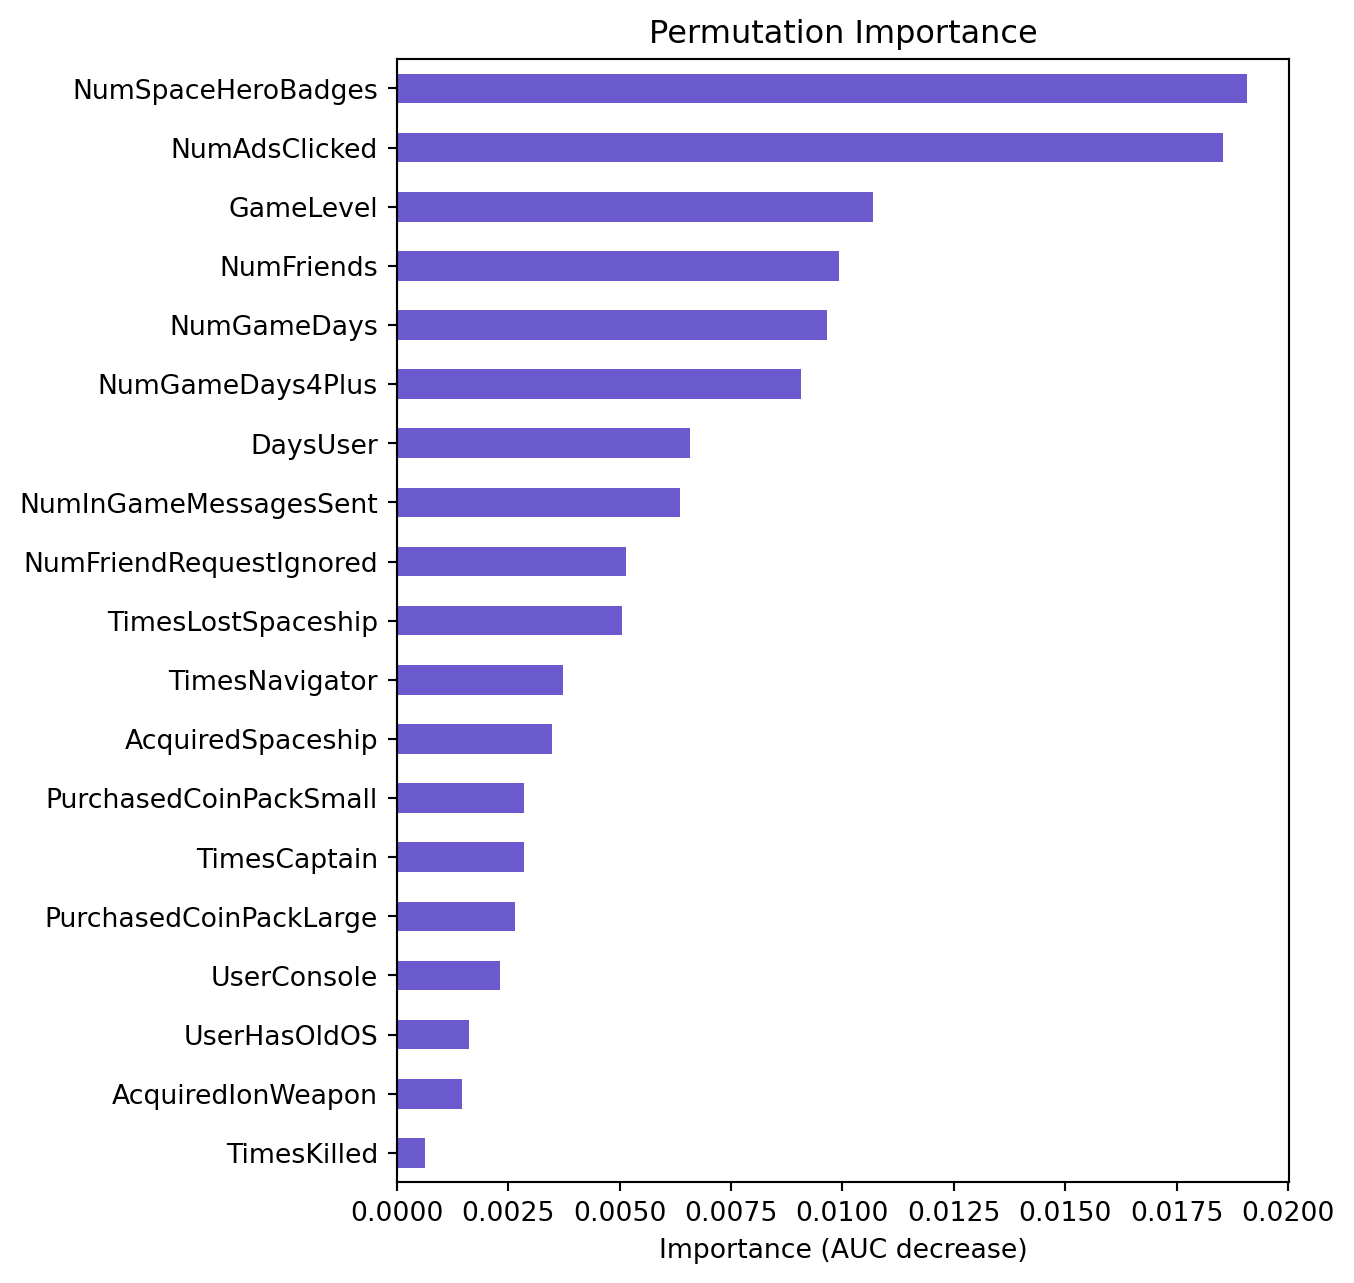

In [49]:
clf_nn3_propensity.plot("vimp")

In [50]:
cg_rct_stacked["pred_random_nn"] = clf_nn3_random.predict(cg_rct_stacked)["prediction"]
cg_rct_stacked["pred_control_nn"] = clf_nn3_control.predict(cg_rct_stacked)["prediction"]

In [51]:
cg_rct_stacked["uplift_score_nn"] = cg_rct_stacked.pred_random_nn - cg_rct_stacked.pred_control_nn

In [52]:
(
    cg_rct_stacked[["converted", "ad", "training", "pred_random_nn", "pred_control_nn", "uplift_score_nn"]]
    .query("training == 0")
    .sort_values("uplift_score_nn", ascending=False)
)

,converted,ad,training,pred_random_nn,pred_control_nn,uplift_score_nn
3701,yes,1,0,0.995663,0.001942,0.993722
27772,no,0,0,0.993559,0.002293,0.991266
7743,no,0,0,0.982310,0.000017,0.982293
5721,no,0,0,0.980717,0.000298,0.980419
25650,no,0,0,0.982799,0.011542,0.971257
...,...,...,...,...,...,...
14044,no,1,0,0.002429,0.988460,-0.986031
5850,no,1,0,0.003168,0.990388,-0.987220
2725,no,0,0,0.004356,0.995334,-0.990978
1470,no,1,0,0.000415,0.995905,-0.995490


In [53]:
train_set_nn = cg_rct_stacked[cg_rct_stacked["training"] == True] # Contains only training cg_rct_stacked (training == 1)
test_set_nn = cg_rct_stacked[cg_rct_stacked["training"] == False] # Contains only test cg_rct_stacked (training == 0)

In [54]:
train_ad0_nn = train_set[train_set_nn['ad'] == 0]['converted'].value_counts(normalize=True)
test_ad0_nn = test_set[test_set_nn['ad'] == 0]['converted'].value_counts(normalize=True)

# Count yes/no for ad == 1 in train and test
train_ad1_nn = train_set[train_set_nn['ad'] == 1]['converted'].value_counts(normalize=True)
test_ad1_nn = test_set[test_set_nn['ad'] == 1]['converted'].value_counts(normalize=True)

# Print results
print("Train Ad == 0 (no ad):", train_ad0_nn.to_dict())
print("Test Ad == 0 (no ad):", test_ad0_nn.to_dict())

print("Train Ad == 1 (ad received):", train_ad1_nn.to_dict())
print("Test Ad == 1 (ad received):", test_ad1_nn.to_dict())

Train Ad == 0 (no ad): {'no': 0.9431428571428572, 'yes': 0.056857142857142856}
Test Ad == 0 (no ad): {'no': 0.9431111111111111, 'yes': 0.05688888888888889}
Train Ad == 1 (ad received): {'no': 0.8695714285714286, 'yes': 0.13042857142857142}
Test Ad == 1 (ad received): {'no': 0.8695555555555555, 'yes': 0.13044444444444445}


In [55]:
# Compute uplift table by binning test cg_rct_stacked into 20 quantiles based on uplift scores
tab_nn = rsm.uplift_tab(
    cg_rct_stacked.query("training == 0"),    # Only use test cg_rct_stacked for evaluation
    "converted",                    # Target variable indicating conversion
    "yes",                          # Positive outcome level for conversion
    "uplift_score_nn",                 # Predicted uplift score (model output)
    "ad",                           # Treatment indicator (1 = ad shown, 0 = no ad)
    1,
    qnt=20                          # Divide the cg_rct_stacked into 20 bins instead of the default 10
)

# Display the uplift table
tab_nn

,pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
0,uplift_score_nn,1,0.05,167,450,51,533,123.941839,1.377132,0.275426
1,uplift_score_nn,2,0.10,297,900,109,1038,202.491329,2.249904,0.174037
2,uplift_score_nn,3,0.15,401,1350,132,1495,281.802676,3.131141,0.180783
3,uplift_score_nn,4,0.20,498,1800,158,1977,354.145675,3.934952,0.161614
4,uplift_score_nn,5,0.25,564,2250,177,2421,399.501859,4.438910,0.103874
5,uplift_score_nn,6,0.30,621,2700,194,2935,442.533220,4.917036,0.093593
6,uplift_score_nn,7,0.35,663,3150,205,3399,473.017652,5.255752,0.069626
7,uplift_score_nn,8,0.40,706,3600,220,3869,501.295942,5.569955,0.063641
8,uplift_score_nn,9,0.45,743,4050,232,4326,525.801664,5.842241,0.055964
9,uplift_score_nn,10,0.50,773,4500,239,4762,547.149517,6.079439,0.050612


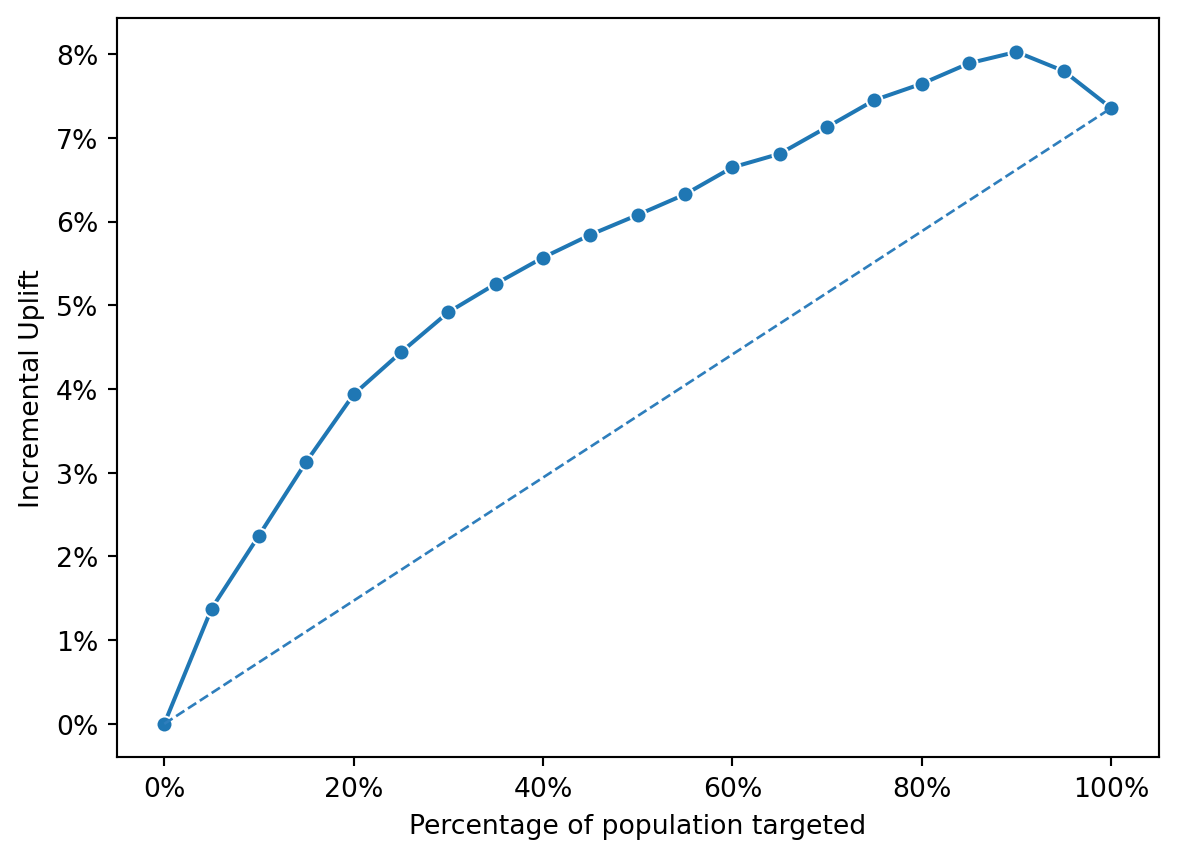

In [56]:
fig_nn = rsm.inc_uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "uplift_score_nn", "ad", 1, qnt = 20)

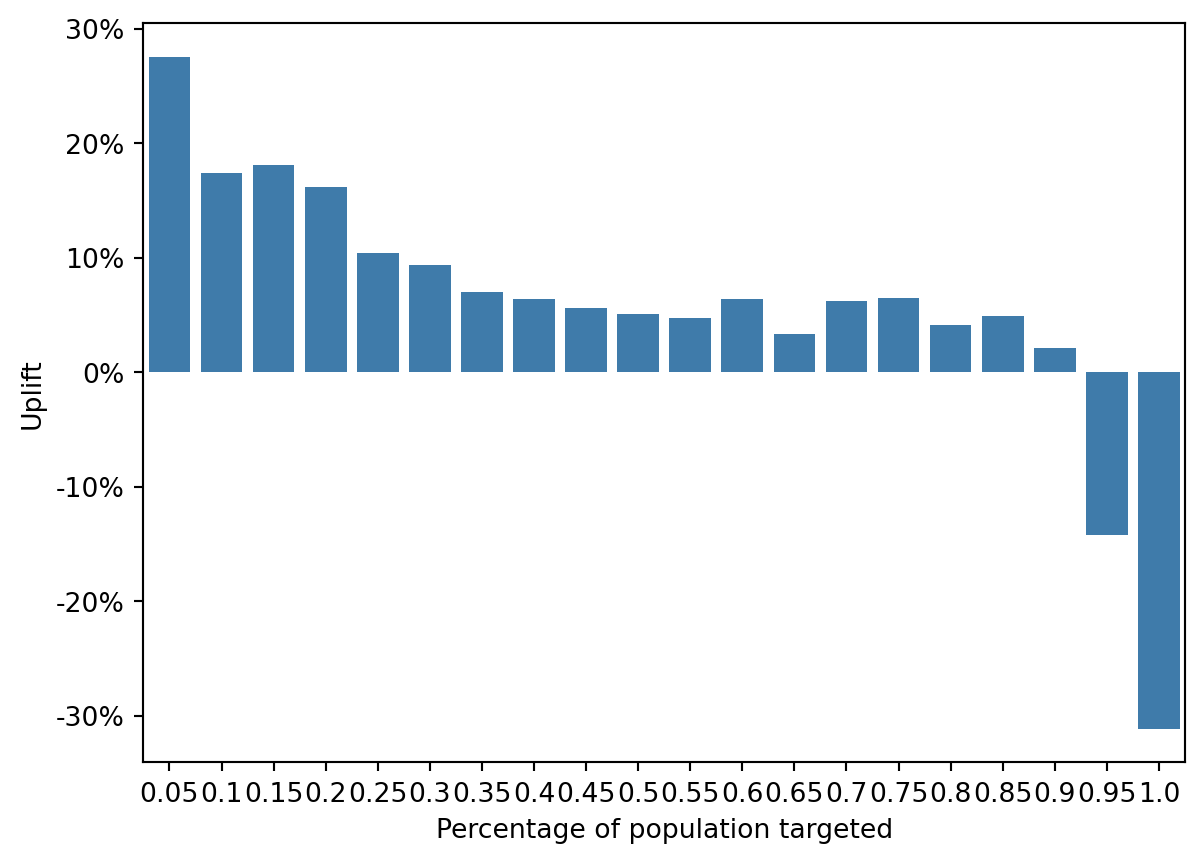

In [57]:
fig_nn = rsm.uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "uplift_score_nn", "ad", 1, qnt = 20)

interpretation

In [58]:
# Step 1: Identify how many bins (quantiles) make up the top 30,000 customers
target_customers = 30000
customers_per_bin = 9000 / 20  # Each quantile bin represents 5% of 9000
bins_needed = target_customers / customers_per_bin  # Find how many bins to sum

# Step 2: Sum the incremental responses from the top bins
incremental_purchases = tab_nn["incremental_resp"][:int(bins_needed)].sum()

# Step 3: Extrapolate to the full population of 120,000 customers
scaling_factor = 120000 / 9000  # Scale from 9,000 to 120,000
expected_incremental_purchases = incremental_purchases * scaling_factor

# Print the result
print(f"Expected incremental purchases if targeting top 30,000 customers: {expected_incremental_purchases:.0f}")

Expected incremental purchases if targeting top 30,000 customers: 139051


In [59]:
# Computing Net Profit

# Step 1: Define known values
price_per_purchase = 14.99  # Price of the Zalon campaign
ad_cost_per_customer = 1.50  # Estimated ad cost per targeted customer

# Step 2: Compute total additional revenue
additional_revenue = expected_incremental_purchases * price_per_purchase

# Step 3: Compute total ad costs (assuming 30,000 customers targeted)
total_ad_costs = 30000 * ad_cost_per_customer  # Since we're targeting 30,000 users

# Step 4: Compute net profit
net_profit = additional_revenue - total_ad_costs

# Step 5: Display the results
print(f"💰 Expected additional revenue from targeting top 30,000 customers: ${additional_revenue:,.2f}")
print(f"📉 Total ad costs for targeting 30,000 customers: ${total_ad_costs:,.2f}")
print(f"✅ Expected Net Profit: ${net_profit:,.2f}")

💰 Expected additional revenue from targeting top 30,000 customers: $2,084,375.07
📉 Total ad costs for targeting 30,000 customers: $45,000.00
✅ Expected Net Profit: $2,039,375.07


In [60]:

clf_nn3_propensity.summary()

Multi-layer Perceptron (NN)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of weights       : 800
Nr. of observations  : 42,000
Hidden_layer_sizes   : (40,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.99
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.82

Raw data             :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriend

In [61]:
cg_rct_stacked["pred_propensity_nn"] = clf_nn3_propensity.predict(cg_rct_stacked)["prediction"]


In [62]:
tab_propensity_nn = rsm.uplift_tab(cg_rct_stacked.query("training == 0"), "converted", "yes", "pred_random_nn", "ad", 1, qnt = 20)
tab_propensity_nn

,pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
0,pred_random_nn,1,0.05,167,450,65,519,110.641618,1.229351,0.245870
1,pred_random_nn,2,0.10,315,900,121,1026,208.859649,2.320663,0.218435
2,pred_random_nn,3,0.15,425,1350,159,1410,272.765957,3.030733,0.145486
3,pred_random_nn,4,0.20,528,1800,195,1868,340.098501,3.778872,0.150286
4,pred_random_nn,5,0.25,603,2250,226,2298,381.720627,4.241340,0.094574
5,pred_random_nn,6,0.30,674,2700,260,2732,417.045388,4.633838,0.079437
6,pred_random_nn,7,0.35,735,3150,291,3213,449.705882,4.996732,0.071106
7,pred_random_nn,8,0.40,781,3600,313,3647,472.033726,5.244819,0.051531
8,pred_random_nn,9,0.45,819,4050,339,4090,483.315403,5.370171,0.025754
9,pred_random_nn,10,0.50,858,4500,355,4505,503.394007,5.593267,0.048112


In [63]:
# expected_incremental_profit = tab_propensity.query("cum_prop >= @proportion").head(1)["incremental_resp"]
# expected_incremental_profit

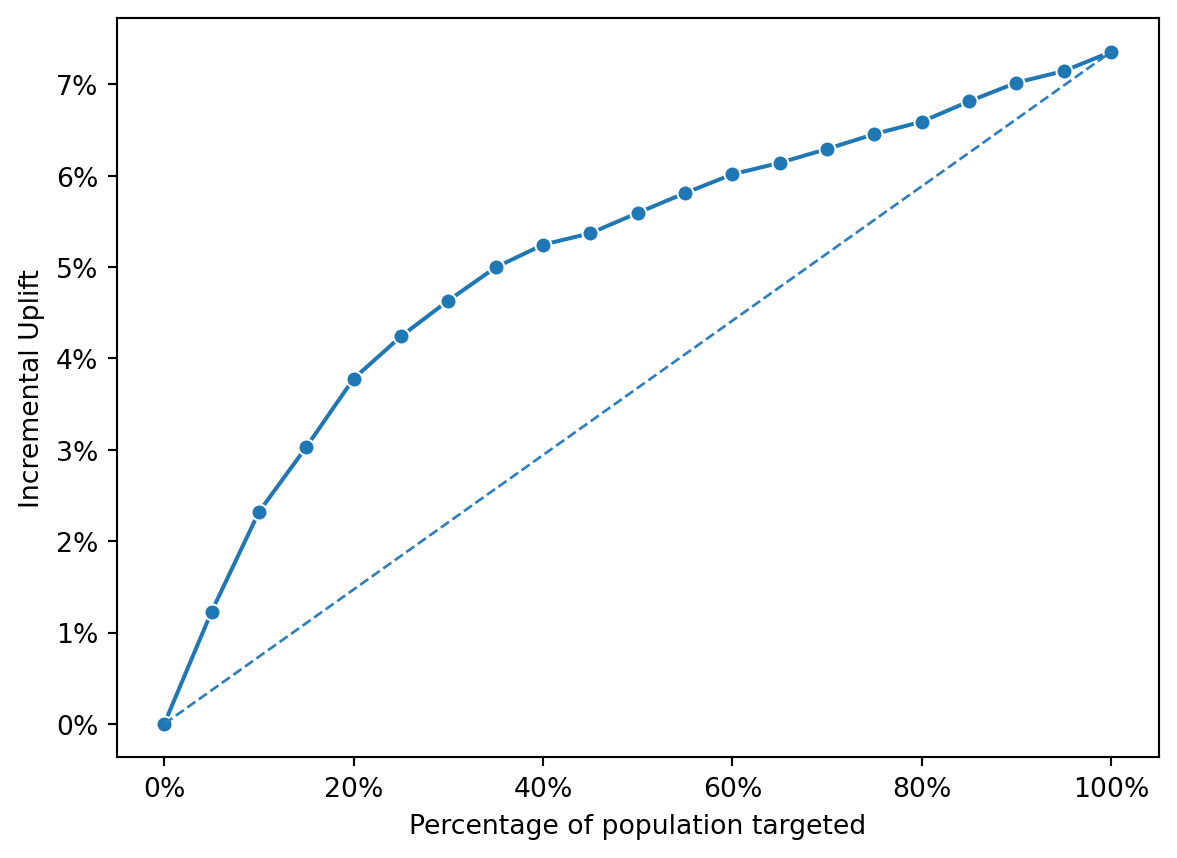

In [64]:
fig_nn = rsm.inc_uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "pred_random_nn", "ad", 1, qnt = 20)

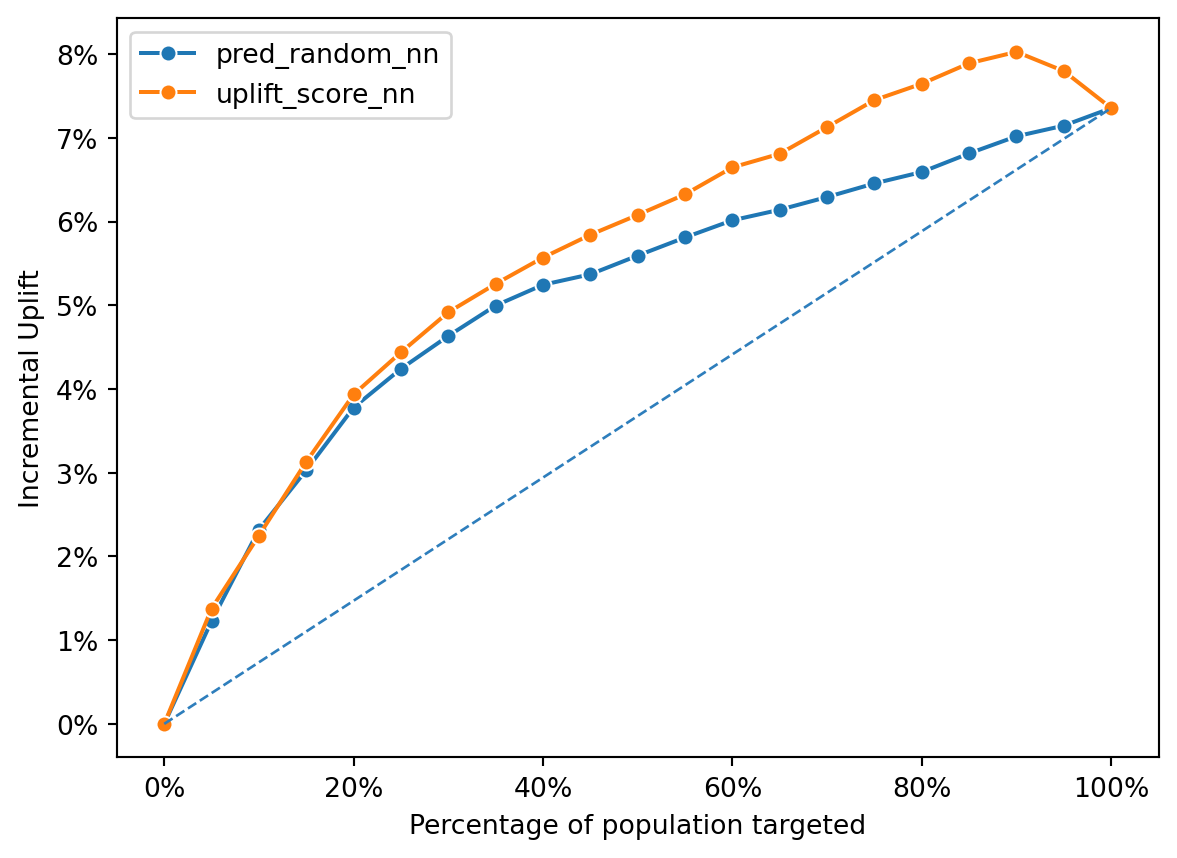

In [65]:
fig_nn = rsm.inc_uplift_plot(
    cg_rct_stacked.query("training == 0"),
    "converted",
    "yes",
    ["pred_random_nn", "uplift_score_nn"],
    "ad",
    1,
    qnt = 20
)

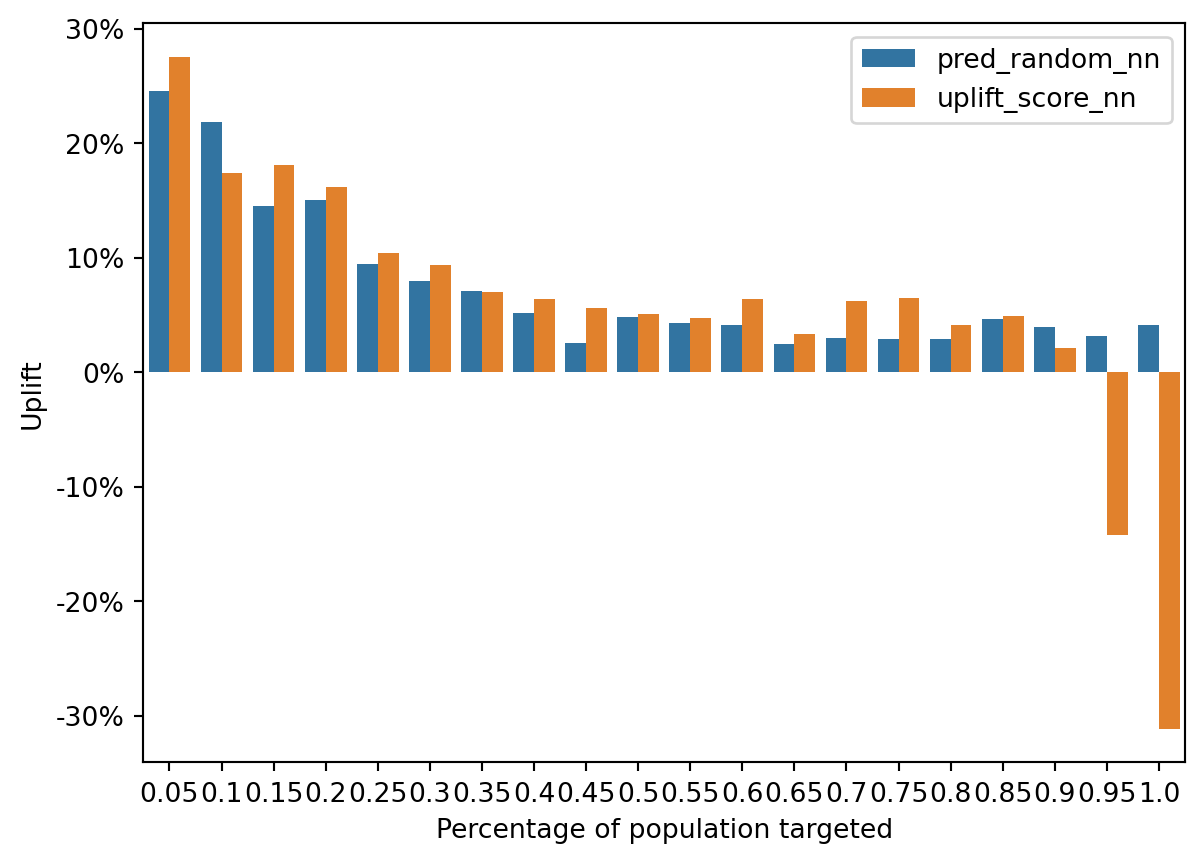

In [66]:
fig_nn = rsm.uplift_plot(
    cg_rct_stacked.query("training == 0"),
    "converted",
    "yes",
    ["pred_random_nn", "uplift_score_nn"],
    "ad",
    1,
    qnt = 20
)

In [67]:
cm = rsm.correlation({"cg_rct_stacked": cg_rct_stacked.loc[cg_rct_stacked.training == 0, "pred_random_nn":"uplift_score_nn"]})
cm.summary()

Correlation
Data     : cg_rct_stacked
Method   : pearson
Cutoff   : 0
Variables: pred_random_nn, pred_control_nn, uplift_score_nn
Null hyp.: variables x and y are not correlated
Alt. hyp.: variables x and y are correlated

Correlation matrix:
                pred_random_nn pred_control_nn
pred_control_nn           0.15                
uplift_score_nn           0.66           -0.65

p.values:
                pred_random_nn pred_control_nn
pred_control_nn            0.0                
uplift_score_nn            0.0             0.0


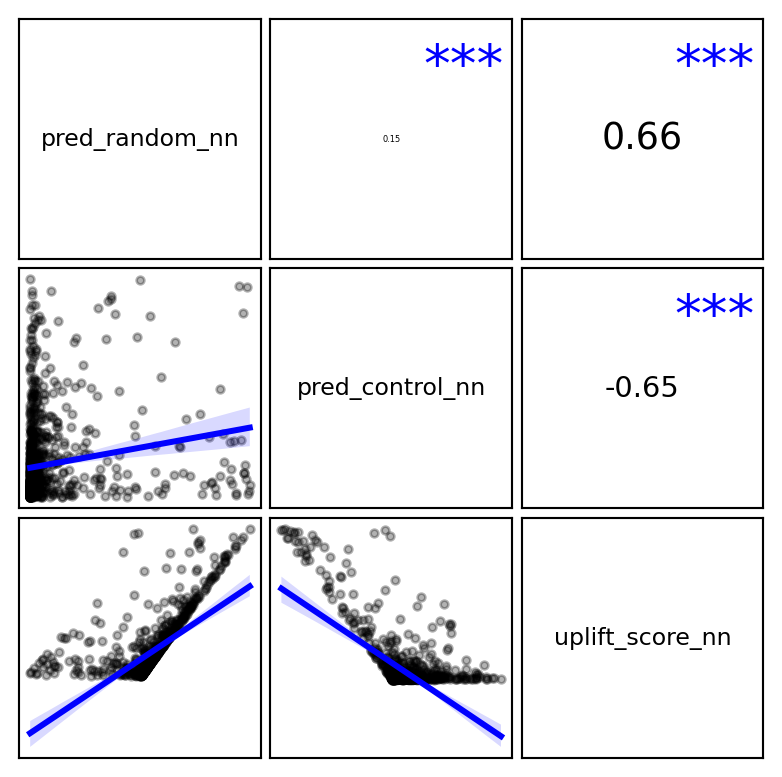

In [68]:
cm.plot()

In [69]:
print(cg_rct_stacked.loc[cg_rct_stacked.training == 0, "pred_random_nn":"uplift_score_nn"].corr().round(2))

                 pred_random_nn  pred_control_nn  uplift_score_nn
pred_random_nn             1.00             0.15             0.66
pred_control_nn            0.15             1.00            -0.65
uplift_score_nn            0.66            -0.65             1.00


In [70]:

# Sum the incremental responses from the top bins
incremental_purchases_prop = tab_propensity_nn["incremental_resp"][:int(bins_needed)].sum()

# Extrapolate to the full population of 120,000 customers

expected_incremental_purchases_prop_nn = incremental_purchases_prop * scaling_factor

# Print the result
print(f"Expected incremental purchases if targeting top 30,000 customers: {expected_incremental_purchases_prop_nn:.0f}")

Expected incremental purchases if targeting top 30,000 customers: 127297


In [71]:
# Computing Net Profit


# Compute total additional revenue
additional_revenue_prop_nn = expected_incremental_purchases_prop_nn * price_per_purchase


# Compute net profit
net_profit_prop_nn = additional_revenue_prop_nn - total_ad_costs

# Display the results
print(f"💰 Expected additional revenue from targeting top 30,000 customers: ${additional_revenue_prop_nn:,.2f}")
print(f"📉 Total ad costs for targeting 30,000 customers: ${total_ad_costs:,.2f}")
print(f"✅ Expected Net Profit: ${net_profit_prop_nn:,.2f}")

💰 Expected additional revenue from targeting top 30,000 customers: $1,908,177.58
📉 Total ad costs for targeting 30,000 customers: $45,000.00
✅ Expected Net Profit: $1,863,177.58


#### 8. Repeat steps 2-6 using a Random Forest model. Tune the model on at least two hyper parameters

In [72]:
cg_uplift_rf_random = rsm.model.rforest(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 1")}, 
    rvar="converted", 
    lev="yes", 
    evar=evar)
cg_uplift_rf_random.summary()

Random Forest
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
OOB                  : True
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 21,000
max_features         : sqrt (4)
n_estimators         : 100
min_samples_leaf     : 1
random_state         : 1234
AUC                  : 0.759

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser  AcquiredSpaceship_yes  AcquiredIonWeapo

In [73]:
cg_uplift_rf_control = rsm.model.rforest(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 0")}, 
    rvar="converted", 
    lev="yes", 
    evar=evar)
cg_uplift_rf_control.summary()

Random Forest
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
OOB                  : True
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 21,000
max_features         : sqrt (4)
n_estimators         : 100
min_samples_leaf     : 1
random_state         : 1234
AUC                  : 0.852

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser  AcquiredSpaceship_yes  AcquiredIonWeapo

Testing out different hyperparameters for the Random Forest models

In [74]:
# Train a Random Forest uplift model for the treatment group (ad == 1)
cg_uplift_rf_random = rsm.model.rforest(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 1")},  # Use only training cg_rct_stacked where ad was shown
    rvar="converted",  # Target variable: whether the user converted
    lev="yes",  # Level of the response variable that indicates a conversion
    evar=evar,  # Explanatory variables used in the model
    n_estimators=300,  # Increased from default (100) to 300 for better accuracy
    min_samples_leaf=5  # Increased from 1 to 5 to prevent overfitting and improve generalization
)

# Print model summary for the treatment group
cg_uplift_rf_random.summary()


# Train a Random Forest uplift model for the control group (ad == 0)
cg_uplift_rf_control = rsm.model.rforest(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 0")},  # Use only training cg_rct_stacked where no ad was shown
    rvar="converted",  # Target variable: whether the user converted
    lev="yes",  # Level of the response variable that indicates a conversion
    evar=evar,  # Explanatory variables used in the model
    n_estimators=300,  # Increased from default (100) to 300 for better accuracy
    min_samples_leaf=5  # Increased from 1 to 5 to prevent overfitting and improve generalization
)

# Print model summary for the control group
cg_uplift_rf_control.summary()

Random Forest
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
OOB                  : True
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 21,000
max_features         : sqrt (4)
n_estimators         : 300
min_samples_leaf     : 5
random_state         : 1234
AUC                  : 0.784

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser  AcquiredSpaceship_yes  AcquiredIonWeapo

Random Forest
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
OOB                  : True
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 21,000
max_features         : sqrt (4)
n_estimators         : 300
min_samples_leaf     : 5
random_state         : 1234
AUC                  : 0.881

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser  AcquiredSpaceship_yes  AcquiredIonWeapo

In [75]:
cg_rct_stacked["pred_rf_random"] = cg_uplift_rf_random.predict(cg_rct_stacked)["prediction"]
cg_rct_stacked["pred_rf_control"] = cg_uplift_rf_control.predict(cg_rct_stacked)["prediction"]

In [76]:
cg_rct_stacked["rf_uplift_score"] = cg_rct_stacked.pred_rf_random - cg_rct_stacked.pred_rf_control

In [77]:
cg_rct_stacked.head()

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,pred_control,uplift_score,pred_propensity,pred_random_nn,pred_control_nn,uplift_score_nn,pred_propensity_nn,pred_rf_random,pred_rf_control,rf_uplift_score
0,no,2,8,0,0,0,5,4,no,no,...,0.009893,0.029967,0.026322,0.001283,0.001119,0.000165,0.011308,0.112040,0.017368,0.094672
1,no,5,15,0,179,0,50,362,yes,no,...,0.011963,0.079347,0.050318,0.004608,0.001257,0.003350,0.006623,0.064115,0.021671,0.042444
2,no,7,7,0,267,0,64,0,no,no,...,0.018791,0.033777,0.040287,0.009954,0.001038,0.008916,0.004624,0.013761,0.000769,0.012992
3,no,4,4,0,36,0,0,0,no,no,...,0.017497,0.023465,0.032032,0.043150,0.004970,0.038180,0.024577,0.026682,0.002023,0.024659
4,no,8,17,0,222,10,63,20,yes,no,...,0.607562,-0.501304,0.229462,0.028837,0.002237,0.026599,0.093688,0.092286,0.184890,-0.092603


In [78]:
# Filtering, selecting, and sorting the cg_rct_stackedset to analyze uplift on test cg_rct_stacked
(
    cg_rct_stacked[["converted", "ad", "training", "pred_rf_random", "pred_rf_control", "rf_uplift_score"]]
    .query("training == 0")
    .sort_values("rf_uplift_score", ascending=False)
)

,converted,ad,training,pred_rf_random,pred_rf_control,rf_uplift_score
9793,no,1,0,0.731165,0.108274,0.622892
11965,no,0,0,0.684685,0.077293,0.607392
19453,no,1,0,0.690552,0.088622,0.601930
8897,no,0,0,0.674072,0.079184,0.594888
8851,no,0,0,0.697208,0.105110,0.592098
...,...,...,...,...,...,...
2985,no,1,0,0.106289,0.706062,-0.599774
561,no,1,0,0.098117,0.701036,-0.602919
20878,no,1,0,0.108864,0.712096,-0.603232
23293,no,1,0,0.086877,0.699689,-0.612813


In [79]:
train_set_rf = cg_rct_stacked[cg_rct_stacked["training"] == True] # Contains only training cg_rct_stacked (training == 1)
test_set_rf = cg_rct_stacked[cg_rct_stacked["training"] == False] # Contains only test cg_rct_stacked (training == 0)

In [80]:
train_ad0_rf = train_set_rf[train_set_rf['ad'] == 0]['converted'].value_counts(normalize=True)
test_ad0_rf = test_set_rf[test_set_rf['ad'] == 0]['converted'].value_counts(normalize=True)

# Count yes/no for ad == 1 in train and test
train_ad1_rf = train_set_rf[train_set_rf['ad'] == 1]['converted'].value_counts(normalize=True)
test_ad1_rf = test_set_rf[test_set_rf['ad'] == 1]['converted'].value_counts(normalize=True)

# Print results
print("Train Ad == 0 (no ad):", train_ad0_rf.to_dict())
print("Test Ad == 0 (no ad):", test_ad0_rf.to_dict())

print("Train Ad == 1 (ad received):", train_ad1_rf.to_dict())
print("Test Ad == 1 (ad received):", test_ad1_rf.to_dict())

Train Ad == 0 (no ad): {'no': 0.9431428571428572, 'yes': 0.056857142857142856}
Test Ad == 0 (no ad): {'no': 0.9431111111111111, 'yes': 0.05688888888888889}
Train Ad == 1 (ad received): {'no': 0.8695714285714286, 'yes': 0.13042857142857142}
Test Ad == 1 (ad received): {'no': 0.8695555555555555, 'yes': 0.13044444444444445}


In [81]:
# Compute uplift table by binning test cg_rct_stacked into 20 quantiles based on uplift scores
tab_rf = rsm.uplift_tab(
    cg_rct_stacked.query("training == 0"),    # Only use test cg_rct_stacked for evaluation
    "converted",                    # Target variable indicating conversion
    "yes",                          # Positive outcome level for conversion
    "rf_uplift_score",                 # Predicted uplift score (model output)
    "ad",                           # Treatment indicator (1 = ad shown, 0 = no ad)
    1,
    qnt=20                          # Divide the cg_rct_stacked into 20 bins instead of the default 10
)

# Display the uplift table
tab_rf

,pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
0,rf_uplift_score,1,0.05,222,450,69,612,171.264706,1.902941,0.380588
1,rf_uplift_score,2,0.10,359,900,98,1126,280.669627,3.118551,0.248024
2,rf_uplift_score,3,0.15,487,1350,127,1676,384.702864,4.274476,0.231717
3,rf_uplift_score,4,0.20,596,1800,160,2246,467.772039,5.197467,0.184327
4,rf_uplift_score,5,0.25,670,2250,184,2765,520.271248,5.780792,0.118202
5,rf_uplift_score,6,0.30,742,2700,209,3249,568.315789,6.314620,0.108347
6,rf_uplift_score,7,0.35,800,3150,225,3741,610.545309,6.783837,0.096369
7,rf_uplift_score,8,0.40,851,3600,240,4240,647.226415,7.191405,0.083273
8,rf_uplift_score,9,0.45,888,4050,254,4756,671.704794,7.463387,0.055090
9,rf_uplift_score,10,0.50,913,4500,270,5214,679.973533,7.555261,0.020621


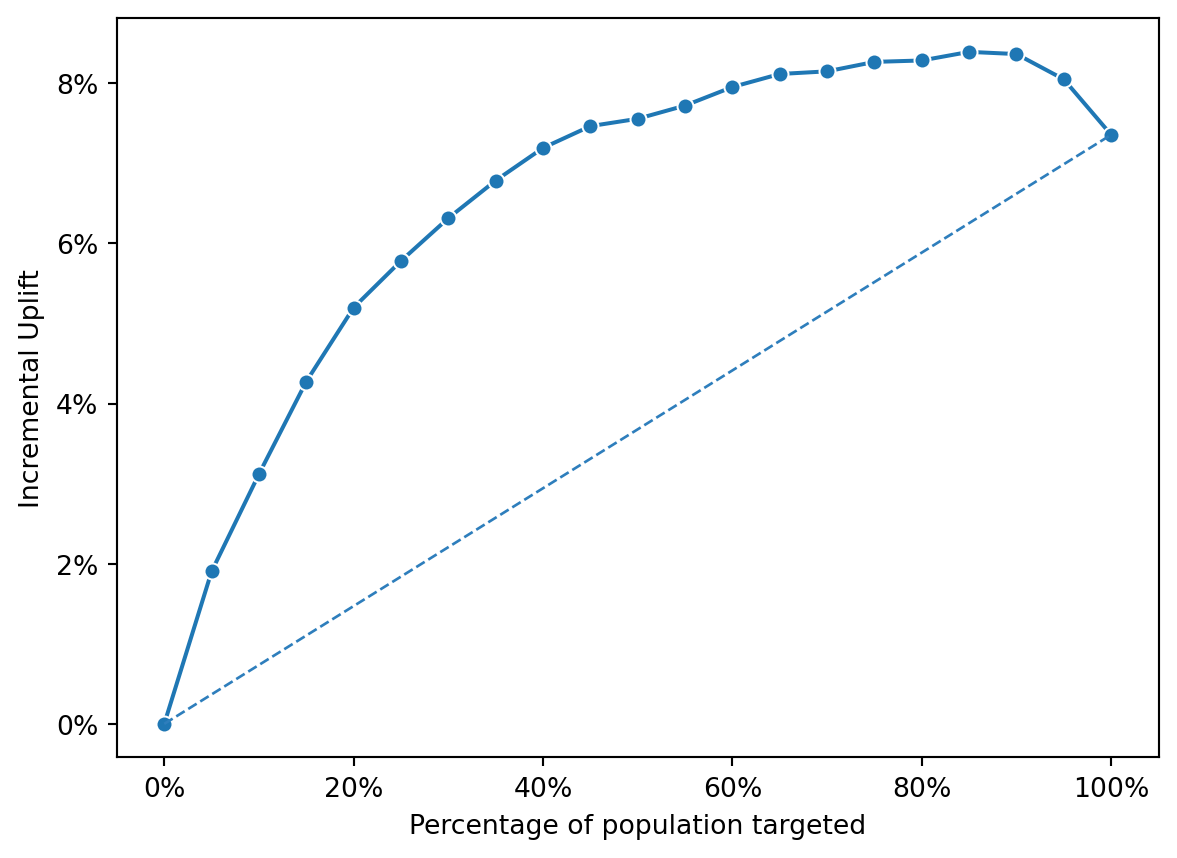

In [82]:
fig_rf = rsm.inc_uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "rf_uplift_score", "ad", 1, qnt = 20)

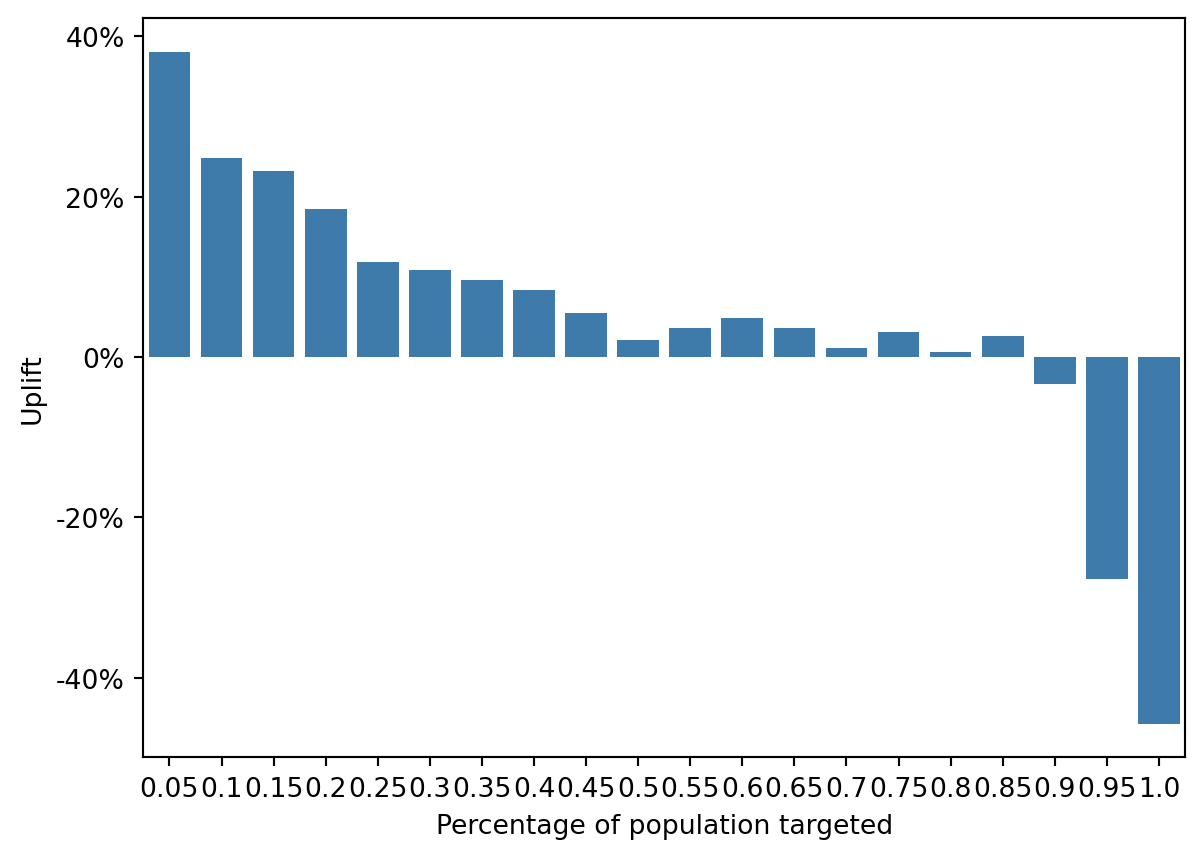

In [83]:
fig_rf = rsm.uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "rf_uplift_score", "ad", 1, qnt = 20)

interpretation

In [84]:
# Step 1: Identify how many bins (quantiles) make up the top 30,000 customers
target_customers = 30000
customers_per_bin = 9000 / 20  # Each quantile bin represents 5% of 9000
bins_needed = target_customers / customers_per_bin  # Find how many bins to sum

# Step 2: Sum the incremental responses from the top bins
incremental_purchases = tab_rf["incremental_resp"][:int(bins_needed)].sum()

# Step 3: Extrapolate to the full population of 120,000 customers
scaling_factor = 120000 / 9000  # Scale from 9,000 to 120,000
expected_incremental_purchases_rf = incremental_purchases * scaling_factor

# Print the result
print(f"Expected incremental purchases if targeting top 30,000 customers: {expected_incremental_purchases_rf:.0f}")

Expected incremental purchases if targeting top 30,000 customers: 163468


In [85]:
# Computing Net Profit

# Step 1: Define known values
price_per_purchase = 14.99  # Price of the Zalon campaign
ad_cost_per_customer = 1.50  # Estimated ad cost per targeted customer

# Step 2: Compute total additional revenue
additional_revenue = expected_incremental_purchases_rf * price_per_purchase

# Step 3: Compute total ad costs (assuming 30,000 customers targeted)
total_ad_costs = 30000 * ad_cost_per_customer  # Since we're targeting 30,000 users

# Step 4: Compute net profit
net_profit = additional_revenue - total_ad_costs

# Step 5: Display the results
print(f"💰 Expected additional revenue from targeting top 30,000 customers: ${additional_revenue:,.2f}")
print(f"📉 Total ad costs for targeting 30,000 customers: ${total_ad_costs:,.2f}")
print(f"✅ Expected Net Profit: ${net_profit:,.2f}")

💰 Expected additional revenue from targeting top 30,000 customers: $2,450,381.20
📉 Total ad costs for targeting 30,000 customers: $45,000.00
✅ Expected Net Profit: $2,405,381.20


In [86]:
cg_uplift_rf_propensity = rsm.model.rforest(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1")}, 
    rvar="converted", 
    lev="yes", 
    evar=evar)
cg_uplift_rf_propensity.summary()

Random Forest
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
OOB                  : True
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 42,000
max_features         : sqrt (4)
n_estimators         : 100
min_samples_leaf     : 1
random_state         : 1234
AUC                  : 0.761

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser  AcquiredSpaceship_yes  AcquiredIonWeapo

In [87]:
cg_rct_stacked["pred_propensity_rf"] = cg_uplift_rf_propensity.predict(cg_rct_stacked)["prediction"]


In [88]:
tab_propensity_rf = rsm.uplift_tab(cg_rct_stacked.query("training == 0"), "converted", "yes", "pred_rf_random", "ad", 1, qnt = 20)
tab_propensity_rf

,pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
0,pred_rf_random,1,0.05,220,450,77,596,161.862416,1.798471,0.359694
1,pred_rf_random,2,0.10,371,900,125,1093,268.072278,2.978581,0.238976
2,pred_rf_random,3,0.15,509,1350,166,1545,363.951456,4.043905,0.215959
3,pred_rf_random,4,0.20,628,1800,226,2037,428.294551,4.758828,0.142493
4,pred_rf_random,5,0.25,706,2250,272,2516,462.756757,5.141742,0.077300
5,pred_rf_random,6,0.30,783,2700,324,2957,487.159621,5.412885,0.053197
6,pred_rf_random,7,0.35,853,3150,371,3370,506.219585,5.624662,0.041754
7,pred_rf_random,8,0.40,917,3600,401,3752,532.245203,5.913836,0.063688
8,pred_rf_random,9,0.45,958,4050,432,4135,534.880290,5.943114,0.010171
9,pred_rf_random,10,0.50,1000,4500,467,4531,536.195100,5.957723,0.004949


In [89]:
# expected_incremental_profit_rf = tab_propensity_rf.query("cum_prop >= @proportion").head(1)["incremental_resp"]
# expected_incremental_profit_rf

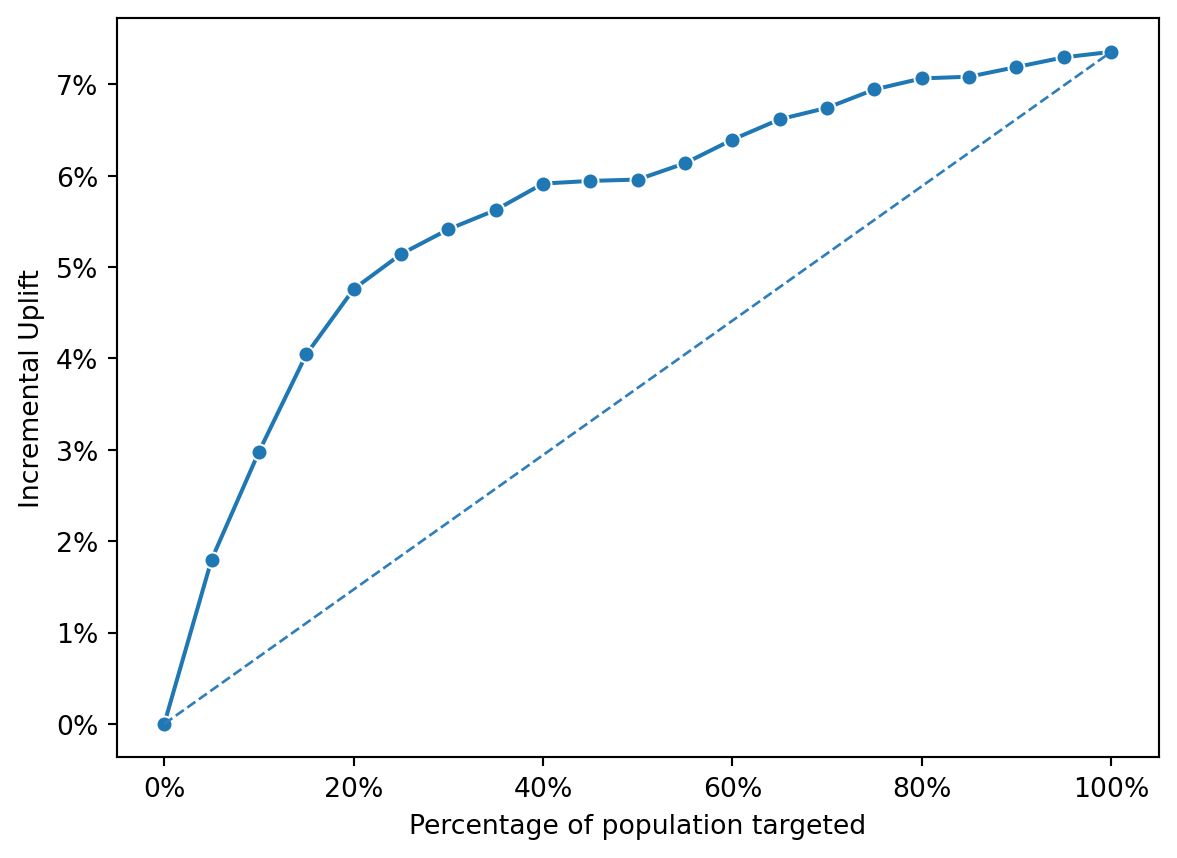

In [90]:
fig_rf = rsm.inc_uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "pred_rf_random", "ad", 1, qnt = 20)

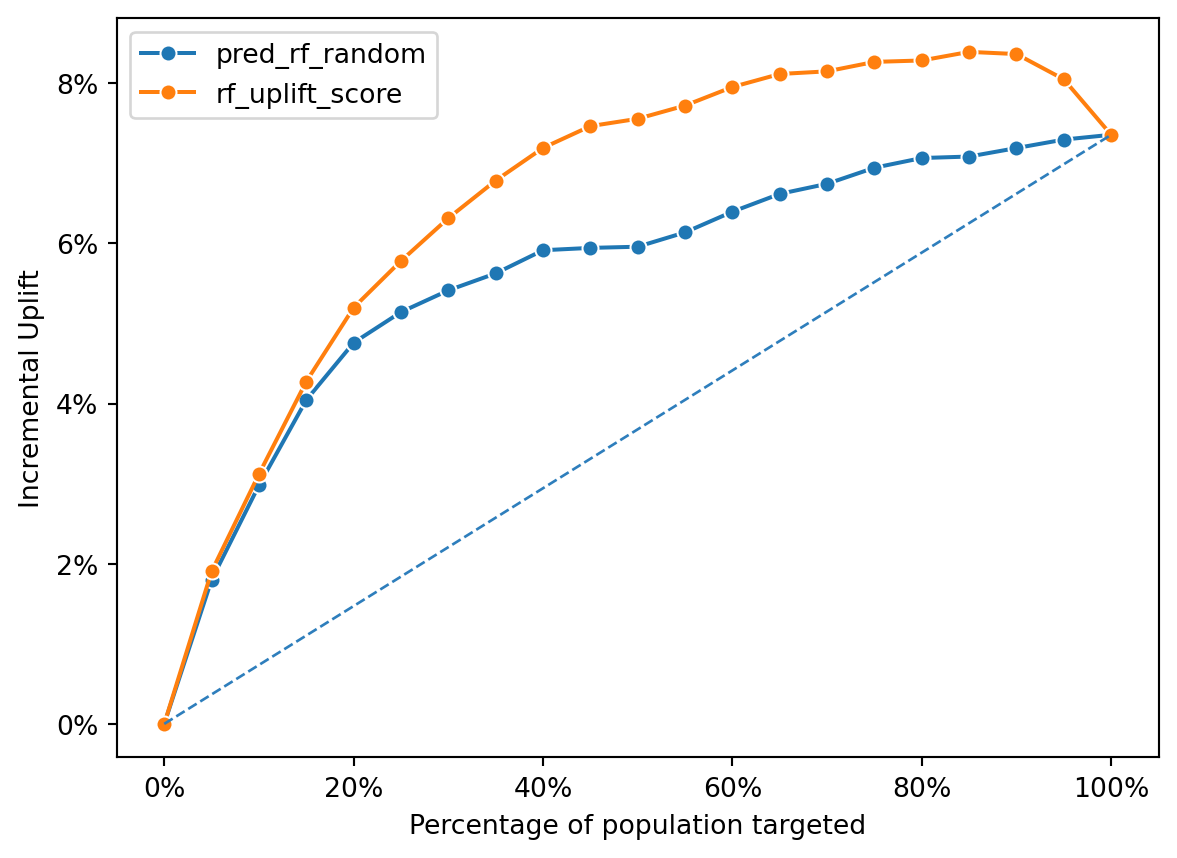

In [91]:
fig_rf = rsm.inc_uplift_plot(
    cg_rct_stacked.query("training == 0"),
    "converted",
    "yes",
    ["pred_rf_random", "rf_uplift_score"],
    "ad",
    1,
    qnt = 20
)

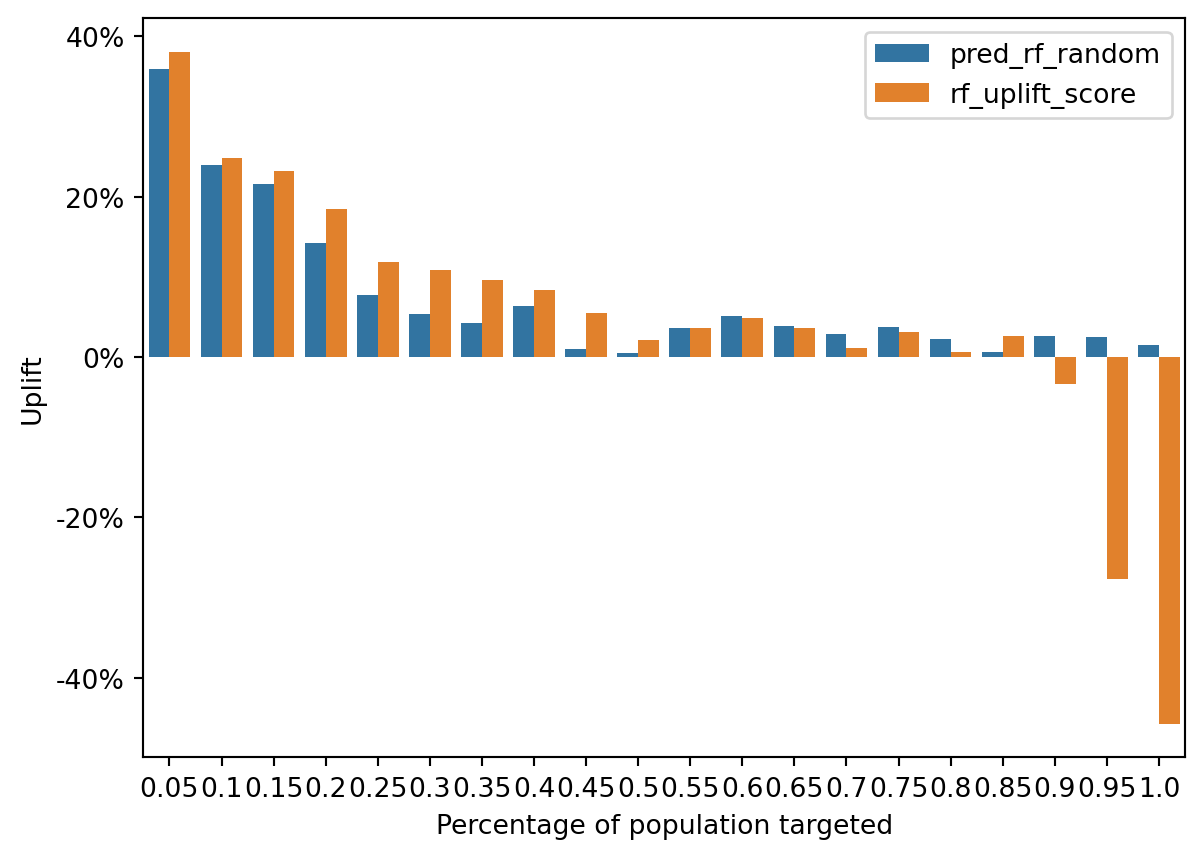

In [92]:
fig_rf = rsm.uplift_plot(
    cg_rct_stacked.query("training == 0"),
    "converted",
    "yes",
    ["pred_rf_random", "rf_uplift_score"],
    "ad",
    1,
    qnt = 20
)

In [93]:
cm = rsm.correlation({"cg_rct_stacked": cg_rct_stacked.loc[cg_rct_stacked.training == 0, "pred_rf_random":"rf_uplift_score"]})
cm.summary()

Correlation
Data     : cg_rct_stacked
Method   : pearson
Cutoff   : 0
Variables: pred_rf_random, pred_rf_control, rf_uplift_score
Null hyp.: variables x and y are not correlated
Alt. hyp.: variables x and y are correlated

Correlation matrix:
                pred_rf_random pred_rf_control
pred_rf_control           0.36                
rf_uplift_score           0.63            -0.5

p.values:
                pred_rf_random pred_rf_control
pred_rf_control            0.0                
rf_uplift_score            0.0             0.0


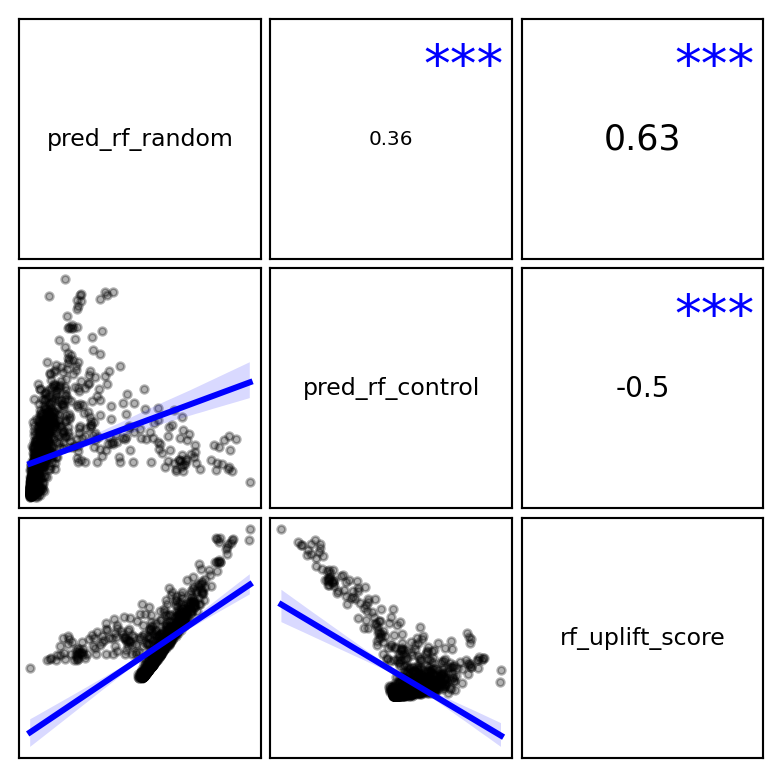

In [94]:
cm.plot()

In [95]:
print(cg_rct_stacked.loc[cg_rct_stacked.training == 0, "pred_rf_random":"rf_uplift_score"].corr().round(2))

                 pred_rf_random  pred_rf_control  rf_uplift_score
pred_rf_random             1.00             0.36             0.63
pred_rf_control            0.36             1.00            -0.50
rf_uplift_score            0.63            -0.50             1.00


In [96]:

# Sum the incremental responses from the top bins
incremental_purchases_prop_rf = tab_propensity_rf["incremental_resp"][:int(bins_needed)].sum()

# Extrapolate to the full population of 120,000 customers

expected_incremental_purchases_prop_rf = incremental_purchases_prop_rf * scaling_factor

# Print the result
print(f"Expected incremental purchases if targeting top 30,000 customers: {expected_incremental_purchases_prop_rf:.0f}")

Expected incremental purchases if targeting top 30,000 customers: 139679


In [97]:
# Computing Net Profit


# Compute total additional revenue
additional_revenue_prop_rf = expected_incremental_purchases_prop_rf * price_per_purchase


# Compute net profit
net_profit_prop_rf = additional_revenue_prop_rf - total_ad_costs

# Display the results
print(f"💰 Expected additional revenue from targeting top 30,000 customers: ${additional_revenue_prop_rf:,.2f}")
print(f"📉 Total ad costs for targeting 30,000 customers: ${total_ad_costs:,.2f}")
print(f"✅ Expected Net Profit: ${net_profit_prop_rf:,.2f}")

💰 Expected additional revenue from targeting top 30,000 customers: $2,093,794.62
📉 Total ad costs for targeting 30,000 customers: $45,000.00
✅ Expected Net Profit: $2,048,794.62


#### 9. Repeat steps 2-6 using an XGBoost model. Tune the model on at least 3 hyper parameters. Do not use “early stopping"

In [98]:
# clf_xgb_pr= rsm.model.xgboost(
#     {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 1")},
#     rvar="converted",
#     lev="yes",
#     evar=evar,
#     n_estimators=100,
#     max_depth=6,
#     min_child_weight=1,
#     learning_rate=0.3,
#     random_state=1234,
# )
# clf_xgb_random.summary()

In [99]:
clf_xgb_random = rsm.model.xgboost(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 1")},
    rvar="converted",
    lev="yes",
    evar=evar,
    n_estimators=100,
    max_depth=6,
    min_child_weight=1,
    learning_rate=0.3,
    random_state=1234,
)
clf_xgb_random.summary()

clf_xgb_control = rsm.model.xgboost(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 0")},
    rvar="converted",
    lev="yes",
    evar=evar,
    n_estimators=100,
    max_depth=6,
    min_child_weight=1,
    learning_rate=0.3,
    random_state=1234,
)
clf_xgb_control.summary()

XGBoost
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 21,000
n_estimators         : 100
max_depth            : 6
min_child_weight     : 1
learning_rate        : 0.3
subsample            : 1.0
colsample_bytree     : 1.0
random_state         : 1234
AUC                  : 0.959

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser 

AUC                  : 0.991

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser  AcquiredSpaceship_yes  AcquiredIonWeapon_yes  PurchasedCoinPackSmall_yes  PurchasedCoinPackLarge_yes  UserConsole_yes  UserHasOldOS_yes
         7           18                 0                    124                   0                       81           0                   8            0             0               4              3      2101                   True                  False                       False                        True            False             False
        10            3                 2                     60                   0                       18         479                  10            7             0               0              7      1644                  False                  Fal

tuning model

In [100]:
clf_xgb_random = rsm.model.xgboost(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 1")},
    rvar="converted",
    lev="yes",
    evar=evar,
    n_estimators=100,
    max_depth=6,
    min_child_weight=1,
    learning_rate=0.3,
    random_state=1234,
)
clf_xgb_random.summary()

clf_xgb_control = rsm.model.xgboost(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1 & ad == 0")},
    rvar="converted",
    lev="yes",
    evar=evar,
    n_estimators=100,
    max_depth=6,
    min_child_weight=1,
    learning_rate=0.3,
    random_state=1234,
)
clf_xgb_control.summary()

XGBoost
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 21,000
n_estimators         : 100
max_depth            : 6
min_child_weight     : 1
learning_rate        : 0.3
subsample            : 1.0
colsample_bytree     : 1.0
random_state         : 1234


AUC                  : 0.959

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser  AcquiredSpaceship_yes  AcquiredIonWeapon_yes  PurchasedCoinPackSmall_yes  PurchasedCoinPackLarge_yes  UserConsole_yes  UserHasOldOS_yes
         5           15                 0                    179                   0                       50         362                  22            0             4               4              2      1308                   True                  False                       False                       False             True             False
         4            4                 0                     36                   0                        0           0                   0            0             0               0              2      2922                  False                  Fal

AUC                  : 0.991

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser  AcquiredSpaceship_yes  AcquiredIonWeapon_yes  PurchasedCoinPackSmall_yes  PurchasedCoinPackLarge_yes  UserConsole_yes  UserHasOldOS_yes
         7           18                 0                    124                   0                       81           0                   8            0             0               4              3      2101                   True                  False                       False                        True            False             False
        10            3                 2                     60                   0                       18         479                  10            7             0               0              7      1644                  False                  Fal

In [101]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": list(range(7)),
    "min_child_weight": [1, 5, 10],
    "learning_rate": [0.1, 0.2, 0.3],
}
scoring = {"AUC": "roc_auc"}
param_grid

{'n_estimators': [50, 100, 150],
 'max_depth': [0, 1, 2, 3, 4, 5, 6],
 'min_child_weight': [1, 5, 10],
 'learning_rate': [0.1, 0.2, 0.3]}

In [102]:
import os
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [103]:

cv_file_random = "cv-objects/clf-xgb-cross-validation-object.pkl"

if os.path.exists(cv_file_random):
    cv = rsm.load_state(cv_file_random)["cv"]
else:
    stratified_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
    cv = GridSearchCV(
        clf_xgb_random.fitted,
        param_grid,
        scoring=scoring,
        cv=stratified_k_fold,
        n_jobs=4,
        refit=list(scoring.keys())[0],
        verbose=5,
    ).fit(clf_xgb_random.cg_rct_stacked_onehot, clf_xgb_random.cg_rct_stacked.converted)

    if not os.path.exists("cv-objects"):
        os.mkdir("cv-objects")

    rsm.save_state({"cv": cv}, cv_file_random)


In [104]:
# cv_file_control = "cv-objects/clf-xgb-cross-validation-object.pkl"
# if os.path.exists(cv_file):
#     cv = rsm.load_state(cv_file)["cv"]
# else:
#     stratified_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
#     cv = GridSearchCV(
#         clf_xgb_control.fitted,
#         param_grid,
#         scoring=scoring,
#         cv=stratified_k_fold,
#         n_jobs=4,
#         refit=list(scoring.keys())[0],
#         verbose=5,
#     ).fit(clf_xgb_control.cg_rct_stacked_onehot, clf_xgb_control.cg_rct_stacked.converted)
#     if not os.path.exists("cv-objects"):
#         os.mkdir("cv-objects")
#     rsm.save_state({"cv": cv}, cv_file)

In [105]:
cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 2,
 'min_child_weight': 10,
 'n_estimators': 150}

In [106]:
cv.best_score_

0.8852325937438369

In [107]:
pd.DataFrame(cv.cv_results_).sort_values("rank_test_AUC")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_min_child_weight,param_n_estimators,params,split0_test_AUC,split1_test_AUC,split2_test_AUC,split3_test_AUC,split4_test_AUC,mean_test_AUC,std_test_AUC,rank_test_AUC
26,0.343602,0.030121,0.021499,0.003327,0.1,2,10,150,"{'learning_rate': 0.1, 'max_depth': 2, 'min_ch...",0.907073,0.909532,0.886522,0.849763,0.873273,0.885233,0.022227,1
34,0.326621,0.025775,0.019564,0.003148,0.1,3,10,100,"{'learning_rate': 0.1, 'max_depth': 3, 'min_ch...",0.906513,0.910203,0.886585,0.851036,0.870836,0.885035,0.022157,2
35,0.405085,0.023904,0.022664,0.002648,0.1,3,10,150,"{'learning_rate': 0.1, 'max_depth': 3, 'min_ch...",0.904248,0.910857,0.884768,0.852371,0.872486,0.884946,0.021262,3
96,0.219814,0.044530,0.016970,0.000445,0.2,3,10,50,"{'learning_rate': 0.2, 'max_depth': 3, 'min_ch...",0.905078,0.909652,0.884224,0.851060,0.874399,0.884882,0.021334,4
93,0.158679,0.026097,0.018909,0.005161,0.2,3,5,50,"{'learning_rate': 0.2, 'max_depth': 3, 'min_ch...",0.903616,0.910684,0.886003,0.852579,0.870616,0.884700,0.021283,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,1.385769,0.115144,0.063063,0.023105,0.2,0,5,150,"{'learning_rate': 0.2, 'max_depth': 0, 'min_ch...",0.864298,0.860343,0.849811,0.819491,0.836779,0.846144,0.016387,185
130,0.750332,0.091219,0.037080,0.003710,0.3,0,5,100,"{'learning_rate': 0.3, 'max_depth': 0, 'min_ch...",0.853662,0.862826,0.849770,0.813500,0.829047,0.841761,0.017944,186
182,0.622291,0.052294,0.029584,0.006761,0.3,6,1,150,"{'learning_rate': 0.3, 'max_depth': 6, 'min_ch...",0.839862,0.868058,0.838937,0.826577,0.835114,0.841710,0.013984,187
134,0.982698,0.174531,0.047472,0.012502,0.3,0,10,150,"{'learning_rate': 0.3, 'max_depth': 0, 'min_ch...",0.853656,0.862084,0.841714,0.818670,0.829065,0.841038,0.015788,188


In [108]:
cg_rct_stacked["pred_xgb_random"] = clf_xgb_random.predict(cg_rct_stacked)["prediction"]
cg_rct_stacked["pred_xgb_control"] = clf_xgb_control.predict(cg_rct_stacked)["prediction"]

In [109]:
cg_rct_stacked["uplift_score_x"] = cg_rct_stacked.pred_xgb_random - cg_rct_stacked.pred_xgb_control

In [110]:
# Filtering, selecting, and sorting the cg_rct_stackedset to analyze uplift on test cg_rct_stacked
(
    cg_rct_stacked[["converted", "ad", "training", "pred_xgb_random", "pred_xgb_control", "uplift_score_x"]]
    .query("training == 0")
    .sort_values("uplift_score_x", ascending=False)
)

,converted,ad,training,pred_xgb_random,pred_xgb_control,uplift_score_x
1268,no,0,0,0.965346,0.005359,0.959988
3448,no,0,0,0.944770,0.003492,0.941278
4833,no,0,0,0.935889,0.012087,0.923803
29000,no,0,0,0.951323,0.028298,0.923025
27365,no,0,0,0.923786,0.001080,0.922706
...,...,...,...,...,...,...
17019,no,1,0,0.032230,0.972876,-0.940647
6756,yes,0,0,0.039613,0.981302,-0.941689
2725,no,0,0,0.022387,0.971438,-0.949051
23293,no,1,0,0.016046,0.980963,-0.964917


In [111]:
train_set_x = cg_rct_stacked[cg_rct_stacked["training"] == True] # Contains only training cg_rct_stacked (training == 1)
test_set_x = cg_rct_stacked[cg_rct_stacked["training"] == False] # Contains only test cg_rct_stacked (training == 0)

In [112]:
train_ad0_x = train_set_x[train_set_x['ad'] == 0]['converted'].value_counts(normalize=True)
test_ad0_x = test_set_x[test_set_x['ad'] == 0]['converted'].value_counts(normalize=True)

# Count yes/no for ad == 1 in train and test
train_ad1_x = train_set_x[train_set_x['ad'] == 1]['converted'].value_counts(normalize=True)
test_ad1_x = test_set_x[test_set_x['ad'] == 1]['converted'].value_counts(normalize=True)

# Print results
print("Train Ad == 0 (no ad):", train_ad0_x.to_dict())
print("Test Ad == 0 (no ad):", test_ad0_x.to_dict())

print("Train Ad == 1 (ad received):", train_ad1_x.to_dict())
print("Test Ad == 1 (ad received):", test_ad1_x.to_dict())

Train Ad == 0 (no ad): {'no': 0.9431428571428572, 'yes': 0.056857142857142856}
Test Ad == 0 (no ad): {'no': 0.9431111111111111, 'yes': 0.05688888888888889}
Train Ad == 1 (ad received): {'no': 0.8695714285714286, 'yes': 0.13042857142857142}
Test Ad == 1 (ad received): {'no': 0.8695555555555555, 'yes': 0.13044444444444445}


In [113]:
# Compute uplift table by binning test cg_rct_stacked into 20 quantiles based on uplift scores
tab_x = rsm.uplift_tab(
    cg_rct_stacked.query("training == 0"),    # Only use test cg_rct_stacked for evaluation
    "converted",                    # Target variable indicating conversion
    "yes",                          # Positive outcome level for conversion
    "uplift_score_x",                 # Predicted uplift score (model output)
    "ad",                           # Treatment indicator (1 = ad shown, 0 = no ad)
    1,
    qnt=20                          # Divide the cg_rct_stacked into 20 bins instead of the default 10
)

# Display the uplift table
tab_x

,pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
0,uplift_score_x,1,0.05,191,450,68,588,138.959184,1.543991,0.308798
1,uplift_score_x,2,0.10,345,900,107,1110,258.243243,2.869369,0.267510
2,uplift_score_x,3,0.15,477,1350,137,1588,360.532746,4.005919,0.230572
3,uplift_score_x,4,0.20,567,1800,167,2097,423.652361,4.707248,0.141061
4,uplift_score_x,5,0.25,654,2250,192,2678,492.685586,5.474284,0.150304
5,uplift_score_x,6,0.30,719,2700,207,3210,544.887850,6.054309,0.116249
6,uplift_score_x,7,0.35,757,3150,223,3662,565.178591,6.279762,0.049046
7,uplift_score_x,8,0.40,803,3600,234,4149,599.963124,6.666257,0.079635
8,uplift_score_x,9,0.45,840,4050,241,4616,628.550693,6.983897,0.067233
9,uplift_score_x,10,0.50,875,4500,258,5102,647.442180,7.193802,0.042798


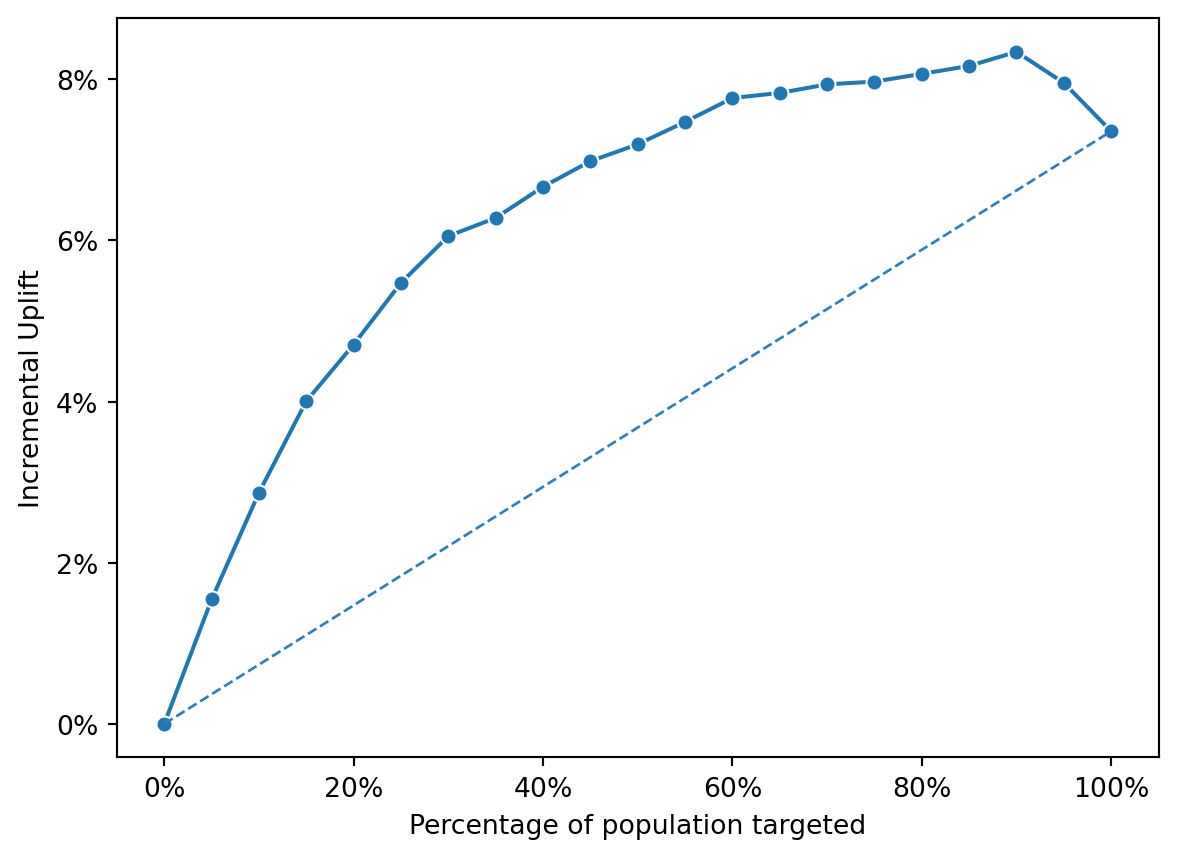

In [114]:
fig_x = rsm.inc_uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "uplift_score_x", "ad", 1, qnt = 20)

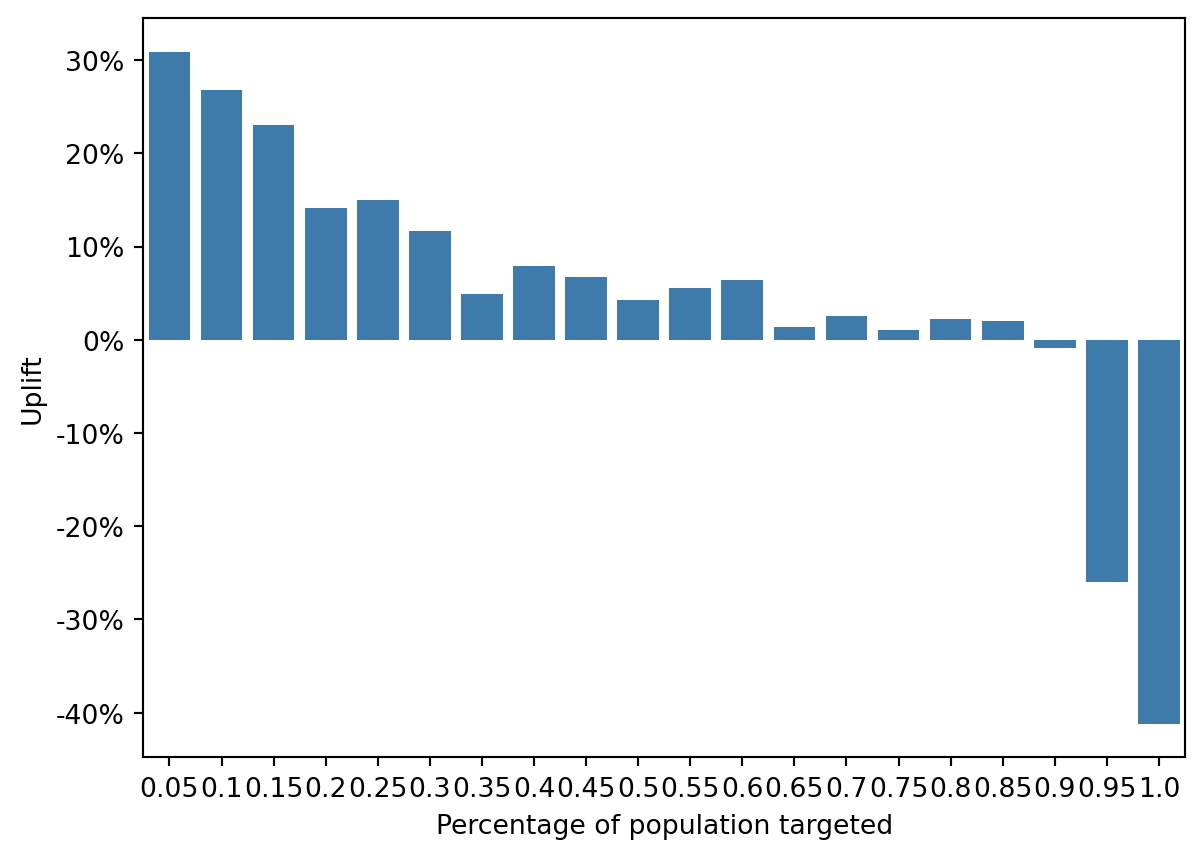

In [115]:
fig_x = rsm.uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "uplift_score_x", "ad", 1, qnt = 20)

interpretation

In [116]:
# Step 1: Identify how many bins (quantiles) make up the top 30,000 customers
target_customers = 30000
customers_per_bin = 9000 / 20  # Each quantile bin represents 5% of 9000
bins_needed = target_customers / customers_per_bin  # Find how many bins to sum

# Step 2: Sum the incremental responses from the top bins
incremental_purchases = tab_x["incremental_resp"][:int(bins_needed)].sum()

# Step 3: Extrapolate to the full population of 120,000 customers
scaling_factor = 120000 / 9000  # Scale from 9,000 to 120,000
expected_incremental_purchases = incremental_purchases * scaling_factor

# Print the result
print(f"Expected incremental purchases if targeting top 30,000 customers: {expected_incremental_purchases:.0f}")

Expected incremental purchases if targeting top 30,000 customers: 156775


In [117]:
# Computing Net Profit

# Step 1: Define known values
price_per_purchase = 14.99  # Price of the Zalon campaign
ad_cost_per_customer = 1.50  # Estimated ad cost per targeted customer

# Step 2: Compute total additional revenue
additional_revenue = expected_incremental_purchases * price_per_purchase

# Step 3: Compute total ad costs (assuming 30,000 customers targeted)
total_ad_costs = 30000 * ad_cost_per_customer  # Since we're targeting 30,000 users

# Step 4: Compute net profit
net_profit = additional_revenue - total_ad_costs

# Step 5: Display the results
print(f"💰 Expected additional revenue from targeting top 30,000 customers: ${additional_revenue:,.2f}")
print(f"📉 Total ad costs for targeting 30,000 customers: ${total_ad_costs:,.2f}")
print(f"✅ Expected Net Profit: ${net_profit:,.2f}")

💰 Expected additional revenue from targeting top 30,000 customers: $2,350,052.42
📉 Total ad costs for targeting 30,000 customers: $45,000.00
✅ Expected Net Profit: $2,305,052.42


In [118]:
clf_xgb_propensity = rsm.model.xgboost(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 1")},
    rvar="converted",
    lev="yes",
    evar=evar,
    n_estimators=100,
    max_depth=6,
    min_child_weight=1,
    learning_rate=0.3,
    random_state=1234,
)
clf_xgb_propensity.summary()

XGBoost
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 42,000
n_estimators         : 100
max_depth            : 6
min_child_weight     : 1
learning_rate        : 0.3
subsample            : 1.0
colsample_bytree     : 1.0
random_state         : 1234
AUC                  : 0.928

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser 

In [119]:
cg_rct_stacked["pred_propensity_x"] = clf_xgb_propensity.predict(cg_rct_stacked)["prediction"]


In [120]:
tab_propensity_x = rsm.uplift_tab(cg_rct_stacked.query("training == 0"), "converted", "yes", "pred_xgb_random", "ad", 1, qnt = 20)
tab_propensity_x

,pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
0,pred_xgb_random,1,0.05,202,450,74,537,139.988827,1.555431,0.311086
1,pred_xgb_random,2,0.10,349,900,123,1048,243.370229,2.704114,0.230776
2,pred_xgb_random,3,0.15,484,1350,165,1461,331.535934,3.683733,0.198305
3,pred_xgb_random,4,0.20,590,1800,211,1899,390.000000,4.333333,0.130533
4,pred_xgb_random,5,0.25,673,2250,245,2370,440.405063,4.893390,0.112258
5,pred_xgb_random,6,0.30,753,2700,284,2894,488.038010,5.422645,0.103350
6,pred_xgb_random,7,0.35,819,3150,311,3347,526.305049,5.847834,0.087064
7,pred_xgb_random,8,0.40,874,3600,349,3769,540.648979,6.007211,0.032175
8,pred_xgb_random,9,0.45,930,4050,376,4273,573.622747,6.373586,0.070873
9,pred_xgb_random,10,0.50,967,4500,398,4653,582.087041,6.467634,0.024327


In [121]:
# expected_incremental_profit_x = tab_propensity_x.query("cum_prop >= @proportion").head(1)["incremental_resp"]
# expected_incremental_profit_x

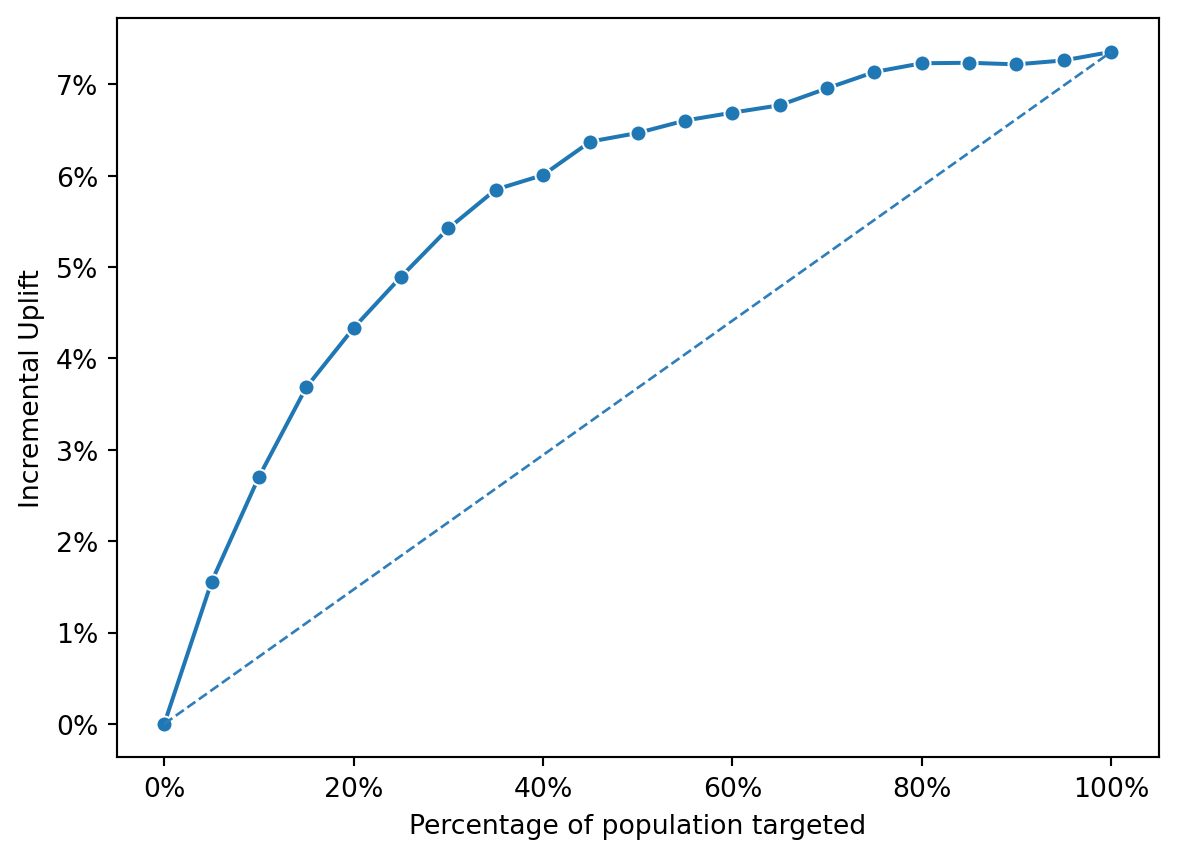

In [122]:
fig_x = rsm.inc_uplift_plot(cg_rct_stacked.query("training == 0"), "converted", "yes", "pred_xgb_random", "ad", 1, qnt = 20)

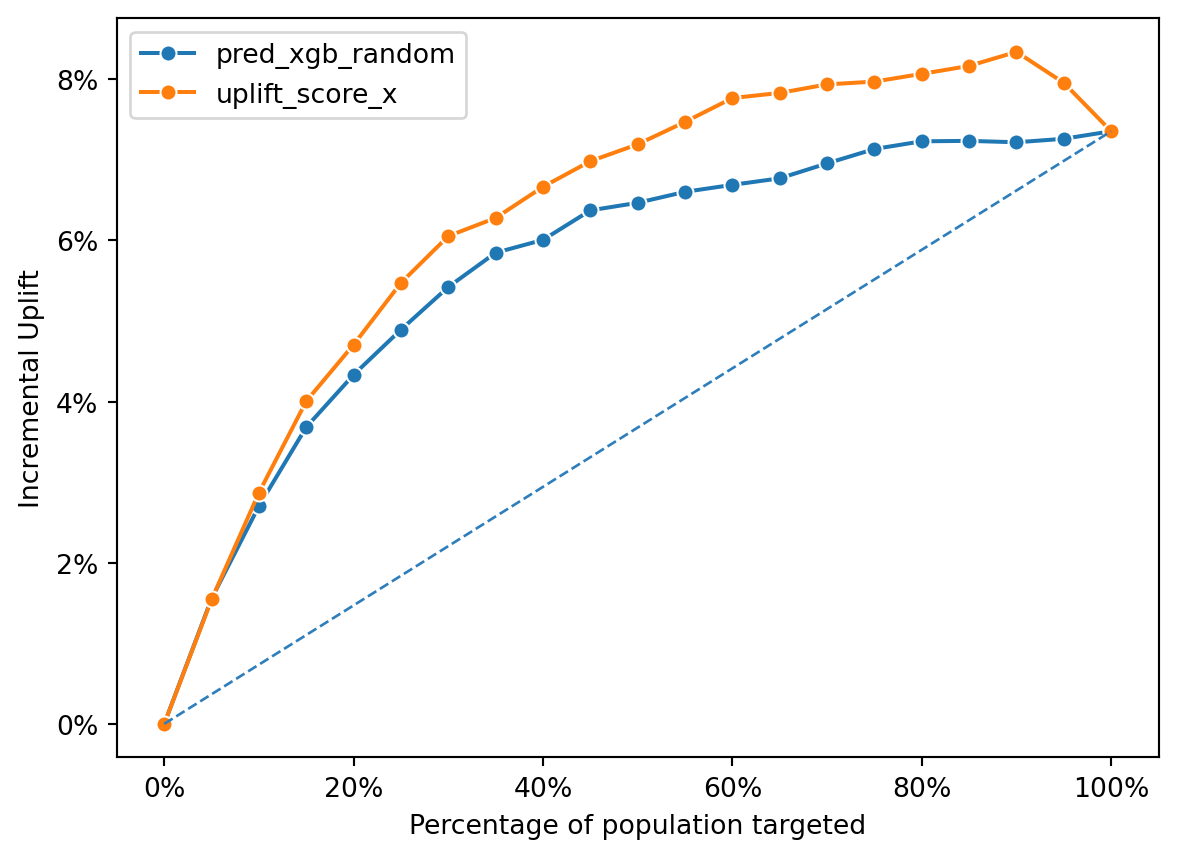

In [123]:
fig_x = rsm.inc_uplift_plot(
    cg_rct_stacked.query("training == 0"),
    "converted",
    "yes",
    ["pred_xgb_random", "uplift_score_x"],
    "ad",
    1,
    qnt = 20
)

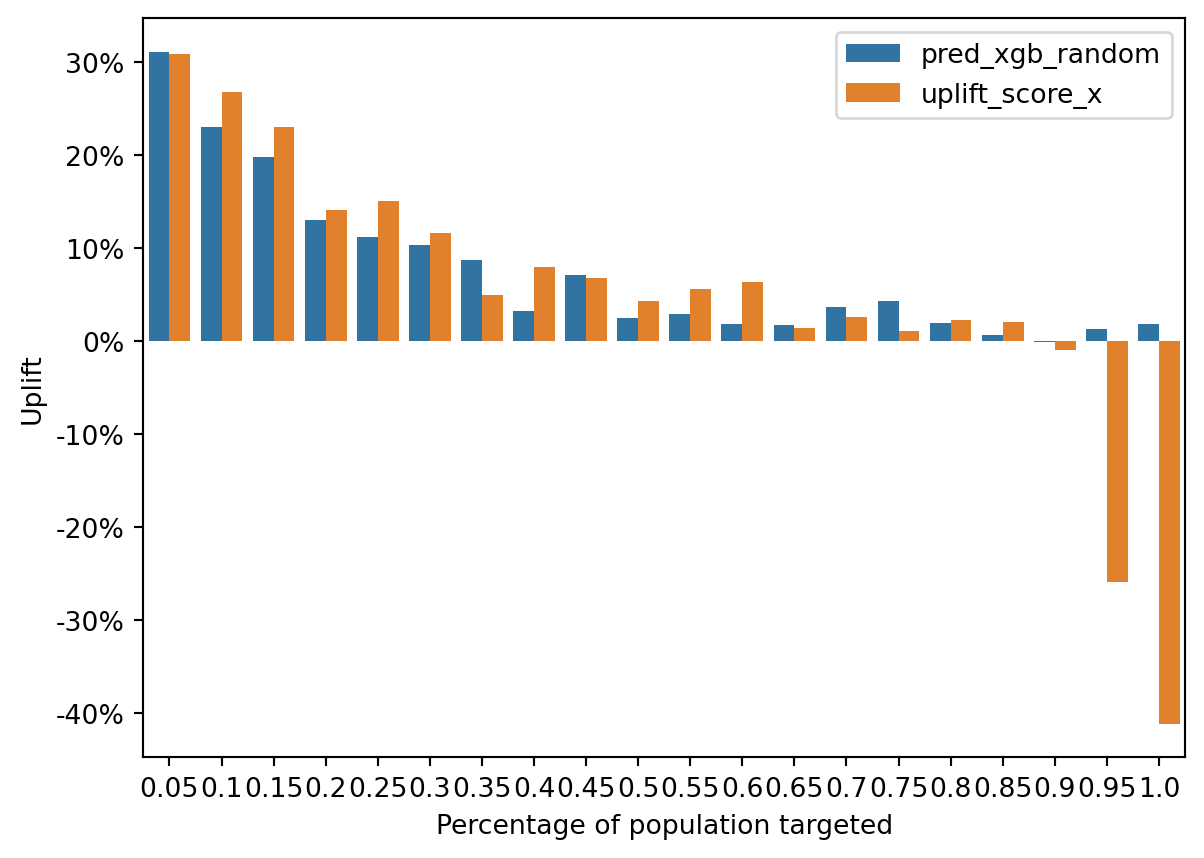

In [124]:
fig_x = rsm.uplift_plot(
    cg_rct_stacked.query("training == 0"),
    "converted",
    "yes",
    ["pred_xgb_random", "uplift_score_x"],
    "ad",
    1,
    qnt = 20
)

In [125]:
cm = rsm.correlation({"cg_rct_stacked": cg_rct_stacked.loc[cg_rct_stacked.training == 0, "pred_xgb_random":"uplift_score_x"]})
cm.summary()

Correlation
Data     : cg_rct_stacked
Method   : pearson
Cutoff   : 0
Variables: pred_xgb_random, pred_xgb_control, uplift_score_x
Null hyp.: variables x and y are not correlated
Alt. hyp.: variables x and y are correlated

Correlation matrix:
                 pred_xgb_random pred_xgb_control
pred_xgb_control            0.19                 
uplift_score_x              0.68             -0.6

p.values:
                 pred_xgb_random pred_xgb_control
pred_xgb_control             0.0                 
uplift_score_x               0.0              0.0


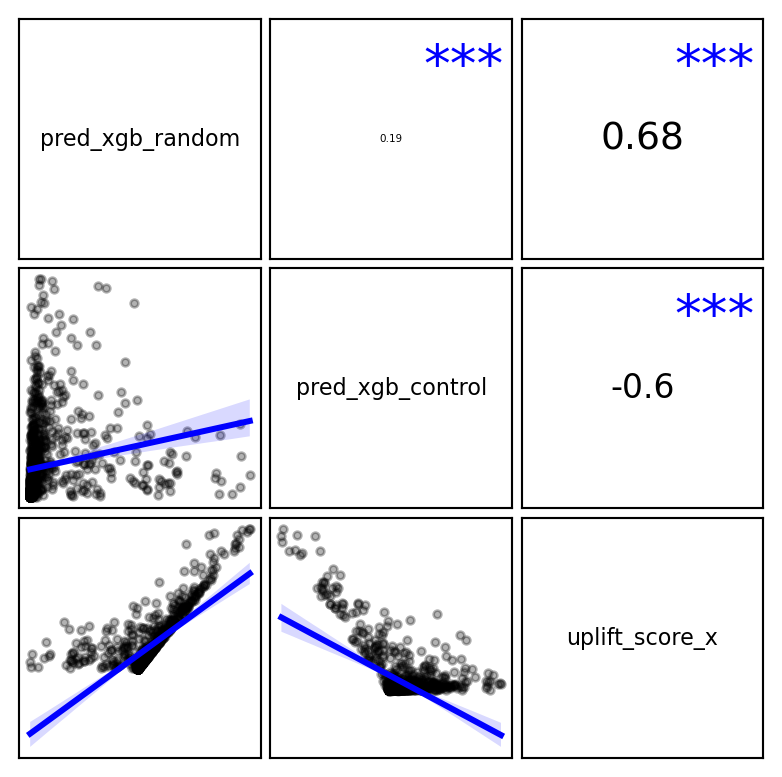

In [126]:
cm.plot()

In [127]:
print(cg_rct_stacked.loc[cg_rct_stacked.training == 0, "pred_xgb_random":"uplift_score_x"].corr().round(2))

                  pred_xgb_random  pred_xgb_control  uplift_score_x
pred_xgb_random              1.00              0.19            0.68
pred_xgb_control             0.19              1.00           -0.60
uplift_score_x               0.68             -0.60            1.00


In [128]:

# Sum the incremental responses from the top bins
incremental_purchases_prop_x = tab_propensity_x["incremental_resp"][:int(bins_needed)].sum()

# Extrapolate to the full population of 120,000 customers

expected_incremental_purchases_prop_x = incremental_purchases_prop_x * scaling_factor

# Print the result
print(f"Expected incremental purchases if targeting top 30,000 customers: {expected_incremental_purchases_prop_x:.0f}")

Expected incremental purchases if targeting top 30,000 customers: 141299


In [129]:
# Computing Net Profit


# Compute total additional revenue
additional_revenue_prop_x = expected_incremental_purchases_prop_x * price_per_purchase


# Compute net profit
net_profit_prop_x = additional_revenue_prop_x - total_ad_costs

# Display the results
print(f"💰 Expected additional revenue from targeting top 30,000 customers: ${additional_revenue_prop_x:,.2f}")
print(f"📉 Total ad costs for targeting 30,000 customers: ${total_ad_costs:,.2f}")
print(f"✅ Expected Net Profit: ${net_profit_prop_x:,.2f}")

💰 Expected additional revenue from targeting top 30,000 customers: $2,118,076.13
📉 Total ad costs for targeting 30,000 customers: $45,000.00
✅ Expected Net Profit: $2,073,076.13


In [130]:
import pandas as pd

# Load the Parquet file
random_parquet = pd.read_parquet("data/cg_ad_random.parquet")

# Get the number of rows
num_rows = len(random_parquet)

print(f"✅ Number of rows in the Parquet file: {num_rows}")

✅ Number of rows in the Parquet file: 30000


In [131]:
# Load the Parquet file
organic_control_parquet = pd.read_parquet("data/cg_organic_control.parquet")

# Get the number of rows
num_rows = len(random_parquet)

print(f"✅ Number of rows in the Parquet file: {num_rows}")

✅ Number of rows in the Parquet file: 30000


In [132]:
# Load the Parquet file
treatment_parquet = pd.read_parquet("data/cg_ad_treatment.parquet")

# Get the number of rows
num_rows = len(treatment_parquet)

print(f"✅ Number of rows in the Parquet file: {num_rows}")

✅ Number of rows in the Parquet file: 150000


### Part 2 Targeting the optimal proportion of customers

#### So far, we have targeted 25% of model-selected customers by picking the best 30,000 out of the set of 120,000 customers. Determine if more or less than 25% of customers should be targeted. 

#### 1. What formula would you use to select customers to target using a propensity model if your goal is to maximize expected profits? What percentage of customers in the ad treatment test set in cg_rct_stacked would you target based on a propensity model?

Pr(Buy|treatment) > (Cost of Offer / Margin on sale)

Pr(Buy|treatment) x Margin on Sale - Cost of Offer > 0

In [133]:
revenue_per_purchase = 14.99  # Price of Zalon campaign
ad_cost_per_customer = 1.50   # Ad cost

breakeven_rate = ad_cost_per_customer / revenue_per_purchase

cg_rct_stacked["maximize_profits_propensity_model"] = cg_rct_stacked.query("training == 0 & ad == 1")["pred_propensity"] * revenue_per_purchase - ad_cost_per_customer > 0

cg_rct_stacked

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,pred_propensity_nn,pred_rf_random,pred_rf_control,rf_uplift_score,pred_propensity_rf,pred_xgb_random,pred_xgb_control,uplift_score_x,pred_propensity_x,maximize_profits_propensity_model
0,no,2,8,0,0,0,5,4,no,no,...,0.011308,0.112040,0.017368,0.094672,0.06,0.067269,0.006424,0.060844,0.022848,False
1,no,5,15,0,179,0,50,362,yes,no,...,0.006623,0.064115,0.021671,0.042444,0.02,0.005465,0.000264,0.005200,0.005113,NaN
2,no,7,7,0,267,0,64,0,no,no,...,0.004624,0.013761,0.000769,0.012992,0.00,0.002662,0.000044,0.002618,0.010835,False
3,no,4,4,0,36,0,0,0,no,no,...,0.024577,0.026682,0.002023,0.024659,0.00,0.039707,0.014905,0.024802,0.044714,NaN
4,no,8,17,0,222,10,63,20,yes,no,...,0.093688,0.092286,0.184890,-0.092603,0.06,0.084544,0.031126,0.053418,0.110367,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,no,10,2,0,14,0,105,0,no,no,...,0.044804,0.051981,0.014708,0.037273,0.05,0.004341,0.001208,0.003133,0.009118,False
29996,no,9,7,0,163,2,83,5,no,no,...,0.316940,0.193766,0.146663,0.047103,0.09,0.104795,0.151846,-0.047051,0.209679,NaN
29997,no,10,15,0,1,1,59,9,no,no,...,0.198061,0.285560,0.085679,0.199882,0.24,0.265886,0.106201,0.159685,0.240502,NaN
29998,no,8,11,0,31,0,0,276,no,no,...,0.155700,0.169559,0.058714,0.110845,0.08,0.111915,0.032416,0.079499,0.054585,True


In [134]:
percentage_target_for_propensity_model = 100 * cg_rct_stacked["maximize_profits_propensity_model"].sum() / len(cg_rct_stacked)

print(f"✅ Percentage of customers targeted by the propensity model: {percentage_target_for_propensity_model:.2f}%")

✅ Percentage of customers targeted by the propensity model: 8.97%


In [135]:
# # Step 1: (Re)define known values
# revenue_per_purchase = 14.99  # Price of Zalon campaign
# ad_cost_per_customer = 1.50  # Estimated ad cost

# # Step 2: Compute the profit per user based on their probability to convert (propensity model)
# cg_rct_stacked["expected_profit"] = (cg_rct_stacked["pred_rf_control"] * revenue_per_purchase) - ad_cost_per_customer

# # Step 3: Determine the percentage of customers where expected profit is positive
# profitable_customers = cg_rct_stacked.query("expected_profit > 0")
# optimal_target_percentage = (len(profitable_customers) / len(cg_rct_stacked)) * 100

# # Step 4: Display the result
# print(f"✅ The optimal percentage of customers to target using a propensity model: {optimal_target_percentage:.2f}%")

#### 2. What formula would you use to select customers to target using an uplift model if your goal is to maximize expected incremental profits? What percentage of customers in the ad treatment test set in cg_rct_stacked would you target based on an uplift model?


Pr(Buy|treatment) x Margin on Sale - Cost of Offer > Pr(Buy|control) x Margin on Sale - Cost of Offer

In [136]:
propensity_profit = cg_rct_stacked.query("training == 0 & ad == 1")["pred_propensity"] * revenue_per_purchase - ad_cost_per_customer
uplift_profit = cg_rct_stacked.query("training == 0 & ad == 1")["uplift_score"] * revenue_per_purchase - ad_cost_per_customer

cg_rct_stacked["maximize_profits_uplift_model"] = propensity_profit > uplift_profit


In [137]:
percentage_target_for_uplift_model = 100 * cg_rct_stacked["maximize_profits_uplift_model"].sum() / len(cg_rct_stacked)

print(f"✅ Percentage of customers targeted by the uplift model: {percentage_target_for_uplift_model:.2f}%")

✅ Percentage of customers targeted by the uplift model: 14.93%


#### 3. Rounding the targeting percentage numbers you calculated in 1. and 2. to the nearest 5%, use the uplift table you created for the propensity and uplift models based on Logistic regression in Part I to extrapolate the incremental profits if you targeted the optimal percentage of customers out of 120K as suggested by the propensity-to-buy and the uplift model.

Consider scaling up to 120,000 (both up and down as needed)

In [138]:
len(cg_rct_stacked)

new_scaling_factor = 120000 / len(cg_rct_stacked)

print(new_scaling_factor)

2.0


In [139]:
# Rounding the percentage_target_for_propensity_model to the nearest 5%
Rounded_uplift_propensity = .10 

New_target_range_propensity = Rounded_uplift_propensity * new_scaling_factor

print(f"New targeting percentage for propensity model: {New_target_range_propensity}")


New targeting percentage for propensity model: 0.2


In [140]:
# Define the new target percentage for the propensity model (20%)
New_target_range_propensity = 0.20  # Targeting 20% of the propensity model users

# Compute the number of bins needed for 20% of users
total_customers_prop = len(cg_rct_stacked.query("training == 0 & ad == 1"))
customers_per_bin_prop = total_customers_prop / 20  # Since qnt=20, each bin is 5% of data
bins_needed_prop = int(New_target_range_propensity * 20)  # Get bins covering 20%

# Train propensity model and compute uplift metrics
tab_propensity = rsm.uplift_tab(
    cg_rct_stacked.query("training == 0"),
    "converted", "yes", "pred_propensity", "ad", 1, qnt=20
)

# Sum incremental responses from top bins covering 20%
incremental_purchases_prop = tab_propensity["incremental_resp"][:bins_needed_prop].sum()

# Scale up for the full population (120,000 users)
scaling_factor_prop = 120000 / total_customers_prop
expected_incremental_purchases_prop = incremental_purchases_prop * scaling_factor_prop

# Compute additional revenue
additional_revenue_prop = expected_incremental_purchases_prop * price_per_purchase

# Compute total ad costs for targeting 20% of users
total_ad_costs_prop = (New_target_range_propensity * 120000) * ad_cost_per_customer

# Compute net profit
net_profit_prop = additional_revenue_prop - total_ad_costs_prop

# Display the results
print(f"🎯 Expected incremental purchases if targeting top 20% of propensity model users: {expected_incremental_purchases_prop:.0f}")
print(f"💰 Expected additional revenue from targeting top 20% propensity users: ${additional_revenue_prop:,.2f}")
print(f"📉 Total ad costs for targeting top 20% propensity users: ${total_ad_costs_prop:,.2f}")
print(f"✅ Expected Net Profit from Propensity Model Targeting: ${net_profit_prop:,.2f}")

🎯 Expected incremental purchases if targeting top 20% of propensity model users: 5739
💰 Expected additional revenue from targeting top 20% propensity users: $86,031.36
📉 Total ad costs for targeting top 20% propensity users: $36,000.00
✅ Expected Net Profit from Propensity Model Targeting: $50,031.36


In [141]:
# Rounding the percentage_target_for_uplift_model to the nearest 5%
Rounded_uplift = .15 

New_target_range = Rounded_uplift * new_scaling_factor

print(f"New targeting percentage for uplift model: {New_target_range}")


New targeting percentage for uplift model: 0.3


In [142]:
# Define the new target percentage for the uplift model (30%)
Rounded_uplift = 0.30  # Targeting 30% of the uplift model users

# Compute the number of bins needed for 30% of users
total_customers_uplift = len(cg_rct_stacked.query("training == 0 & ad == 1"))
customers_per_bin_uplift = total_customers_uplift / 20  # Since qnt=20, each bin is 5% of data
bins_needed_uplift = int(Rounded_uplift * 20)  # Get bins covering 30%

# Train uplift model and compute uplift metrics
tab_uplift = rsm.uplift_tab(
    cg_rct_stacked.query("training == 0"),
    "converted", "yes", "pred_random", "ad", 1, qnt=20
)

# Sum incremental responses from top bins covering 30%
incremental_purchases_uplift = tab_uplift["incremental_resp"][:bins_needed_uplift].sum()

# Scale up for the full population (120,000 users)
scaling_factor_uplift = 120000 / total_customers_uplift
expected_incremental_purchases_uplift = incremental_purchases_uplift * scaling_factor_uplift

# Compute additional revenue
additional_revenue_uplift = expected_incremental_purchases_uplift * price_per_purchase

# Compute total ad costs for targeting 30% of users
total_ad_costs_uplift = (Rounded_uplift * 120000) * ad_cost_per_customer

# Compute net profit
net_profit_uplift = additional_revenue_uplift - total_ad_costs_uplift

# Display the results
print(f"🎯 Expected incremental purchases if targeting top 30% of uplift model users: {expected_incremental_purchases_uplift:.0f}")
print(f"💰 Expected additional revenue from targeting top 30% uplift users: ${additional_revenue_uplift:,.2f}")
print(f"📉 Total ad costs for targeting top 30% uplift users: ${total_ad_costs_uplift:,.2f}")
print(f"✅ Expected Net Profit from Uplift Model Targeting: ${net_profit_uplift:,.2f}")

🎯 Expected incremental purchases if targeting top 30% of uplift model users: 23999
💰 Expected additional revenue from targeting top 30% uplift users: $359,745.22
📉 Total ad costs for targeting top 30% uplift users: $54,000.00
✅ Expected Net Profit from Uplift Model Targeting: $305,745.22


#### 4. Repeat the calculations/analysis from II.3 for the tuned Neural Network model 

In [143]:
cg_rct_stacked["maximize_profits_propensity_model"] = cg_rct_stacked.query("training == 0 & ad == 1")["pred_propensity_nn"] * revenue_per_purchase - ad_cost_per_customer > 0

cg_rct_stacked

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,pred_rf_random,pred_rf_control,rf_uplift_score,pred_propensity_rf,pred_xgb_random,pred_xgb_control,uplift_score_x,pred_propensity_x,maximize_profits_propensity_model,maximize_profits_uplift_model
0,no,2,8,0,0,0,5,4,no,no,...,0.112040,0.017368,0.094672,0.06,0.067269,0.006424,0.060844,0.022848,False,False
1,no,5,15,0,179,0,50,362,yes,no,...,0.064115,0.021671,0.042444,0.02,0.005465,0.000264,0.005200,0.005113,NaN,NaN
2,no,7,7,0,267,0,64,0,no,no,...,0.013761,0.000769,0.012992,0.00,0.002662,0.000044,0.002618,0.010835,False,True
3,no,4,4,0,36,0,0,0,no,no,...,0.026682,0.002023,0.024659,0.00,0.039707,0.014905,0.024802,0.044714,NaN,NaN
4,no,8,17,0,222,10,63,20,yes,no,...,0.092286,0.184890,-0.092603,0.06,0.084544,0.031126,0.053418,0.110367,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,no,10,2,0,14,0,105,0,no,no,...,0.051981,0.014708,0.037273,0.05,0.004341,0.001208,0.003133,0.009118,False,False
29996,no,9,7,0,163,2,83,5,no,no,...,0.193766,0.146663,0.047103,0.09,0.104795,0.151846,-0.047051,0.209679,NaN,NaN
29997,no,10,15,0,1,1,59,9,no,no,...,0.285560,0.085679,0.199882,0.24,0.265886,0.106201,0.159685,0.240502,NaN,NaN
29998,no,8,11,0,31,0,0,276,no,no,...,0.169559,0.058714,0.110845,0.08,0.111915,0.032416,0.079499,0.054585,True,True


In [144]:
cg_rct_stacked

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,pred_rf_random,pred_rf_control,rf_uplift_score,pred_propensity_rf,pred_xgb_random,pred_xgb_control,uplift_score_x,pred_propensity_x,maximize_profits_propensity_model,maximize_profits_uplift_model
0,no,2,8,0,0,0,5,4,no,no,...,0.112040,0.017368,0.094672,0.06,0.067269,0.006424,0.060844,0.022848,False,False
1,no,5,15,0,179,0,50,362,yes,no,...,0.064115,0.021671,0.042444,0.02,0.005465,0.000264,0.005200,0.005113,NaN,NaN
2,no,7,7,0,267,0,64,0,no,no,...,0.013761,0.000769,0.012992,0.00,0.002662,0.000044,0.002618,0.010835,False,True
3,no,4,4,0,36,0,0,0,no,no,...,0.026682,0.002023,0.024659,0.00,0.039707,0.014905,0.024802,0.044714,NaN,NaN
4,no,8,17,0,222,10,63,20,yes,no,...,0.092286,0.184890,-0.092603,0.06,0.084544,0.031126,0.053418,0.110367,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,no,10,2,0,14,0,105,0,no,no,...,0.051981,0.014708,0.037273,0.05,0.004341,0.001208,0.003133,0.009118,False,False
29996,no,9,7,0,163,2,83,5,no,no,...,0.193766,0.146663,0.047103,0.09,0.104795,0.151846,-0.047051,0.209679,NaN,NaN
29997,no,10,15,0,1,1,59,9,no,no,...,0.285560,0.085679,0.199882,0.24,0.265886,0.106201,0.159685,0.240502,NaN,NaN
29998,no,8,11,0,31,0,0,276,no,no,...,0.169559,0.058714,0.110845,0.08,0.111915,0.032416,0.079499,0.054585,True,True


In [145]:
print(cg_rct_stacked.query("training == 0 & ad == 1")["maximize_profits_uplift_model"].value_counts())

maximize_profits_uplift_model
False    4522
True     4478
Name: count, dtype: int64


In [146]:
print(cg_rct_stacked["maximize_profits_uplift_model"].isna().sum())

42000


In [147]:
cg_rct_stacked["maximize_profits_uplift_model"] = cg_rct_stacked["maximize_profits_uplift_model"].fillna(False)

/tmp/ipykernel_17936/4218204075.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cg_rct_stacked["maximize_profits_uplift_model"] = cg_rct_stacked["maximize_profits_uplift_model"].fillna(False)


In [148]:
print(cg_rct_stacked["maximize_profits_uplift_model"].isna().sum())

0


In [149]:
# Create a categorical version of maximize_profits_uplift_model using "yes" and "no"
cg_rct_stacked["maximize_profits_uplift_model_category"] = cg_rct_stacked["maximize_profits_uplift_model"].map({
    True: "yes",
    False: "no"
})

# Display value counts to confirm the change
print(cg_rct_stacked["maximize_profits_uplift_model_category"].value_counts())

maximize_profits_uplift_model_category
no     51044
yes     8956
Name: count, dtype: int64


In [150]:

# Train the Neural Network model
cg_uplift_nn_propensity_120k = rsm.model.mlp(
    {"data": cg_rct_stacked.query("training == 0 & ad == 1")},  # Ensure correct data format
    hidden_layer_sizes=(5,),  # Small NN with 5 hidden units
    alpha=.001,  # Regularization parameter
    rvar="maximize_profits_uplift_model_category",   # Response variable (target)
    lev="yes",  # Target level (ensure correct format in data)
    evar=evar  # Explanatory variables (features)
)

# Print model summary
cg_uplift_nn_propensity_120k.summary()


Multi-layer Perceptron (NN)
Data                 : data
Response variable    : maximize_profits_uplift_model_category
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of weights       : 100
Nr. of observations  : 9,000
Hidden_layer_sizes   : (5,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 1.0

Raw data             :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestI

In [151]:
cg_uplift_nn_control = rsm.model.mlp(
    {"data": cg_rct_stacked.query("training == 0 & ad == 1")},  # Ensure correct data format
    hidden_layer_sizes=(5,),  # Small NN with 5 hidden units
    alpha=.001,  # Regularization parameter
    rvar="maximize_profits_uplift_model_category",   # Response variable (target)
    lev="yes",  # Target level (ensure correct format in data)
    evar=evar  # Explanatory variables (features)
)

# Print model summary
cg_uplift_nn_control.summary()

Multi-layer Perceptron (NN)
Data                 : data
Response variable    : maximize_profits_uplift_model_category
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of weights       : 100
Nr. of observations  : 9,000
Hidden_layer_sizes   : (5,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 1.0

Raw data             :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestI

In [152]:

cg_rct_stacked["pred_nn_control"] = cg_uplift_nn_control.predict(cg_rct_stacked)["prediction"]

In [153]:
cg_rct_stacked.head()

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,rf_uplift_score,pred_propensity_rf,pred_xgb_random,pred_xgb_control,uplift_score_x,pred_propensity_x,maximize_profits_propensity_model,maximize_profits_uplift_model,maximize_profits_uplift_model_category,pred_nn_control
0,no,2,8,0,0,0,5,4,no,no,...,0.094672,0.06,0.067269,0.006424,0.060844,0.022848,False,False,no,7.673763e-16
1,no,5,15,0,179,0,50,362,yes,no,...,0.042444,0.02,0.005465,0.000264,0.005200,0.005113,NaN,False,no,3.134565e-38
2,no,7,7,0,267,0,64,0,no,no,...,0.012992,0.00,0.002662,0.000044,0.002618,0.010835,False,True,yes,1.000000e+00
3,no,4,4,0,36,0,0,0,no,no,...,0.024659,0.00,0.039707,0.014905,0.024802,0.044714,NaN,False,no,1.000000e+00
4,no,8,17,0,222,10,63,20,yes,no,...,-0.092603,0.06,0.084544,0.031126,0.053418,0.110367,NaN,False,no,1.000000e+00


not testing different hyper-parameters as the instructions did not say to

#### 5. Repeat the calculations/analysis from II.3 for the tuned Random Forest model 

In [154]:
cg_rct_stacked

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,rf_uplift_score,pred_propensity_rf,pred_xgb_random,pred_xgb_control,uplift_score_x,pred_propensity_x,maximize_profits_propensity_model,maximize_profits_uplift_model,maximize_profits_uplift_model_category,pred_nn_control
0,no,2,8,0,0,0,5,4,no,no,...,0.094672,0.06,0.067269,0.006424,0.060844,0.022848,False,False,no,7.673763e-16
1,no,5,15,0,179,0,50,362,yes,no,...,0.042444,0.02,0.005465,0.000264,0.005200,0.005113,NaN,False,no,3.134565e-38
2,no,7,7,0,267,0,64,0,no,no,...,0.012992,0.00,0.002662,0.000044,0.002618,0.010835,False,True,yes,1.000000e+00
3,no,4,4,0,36,0,0,0,no,no,...,0.024659,0.00,0.039707,0.014905,0.024802,0.044714,NaN,False,no,1.000000e+00
4,no,8,17,0,222,10,63,20,yes,no,...,-0.092603,0.06,0.084544,0.031126,0.053418,0.110367,NaN,False,no,1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,no,10,2,0,14,0,105,0,no,no,...,0.037273,0.05,0.004341,0.001208,0.003133,0.009118,False,False,no,1.675978e-35
29996,no,9,7,0,163,2,83,5,no,no,...,0.047103,0.09,0.104795,0.151846,-0.047051,0.209679,NaN,False,no,1.000000e+00
29997,no,10,15,0,1,1,59,9,no,no,...,0.199882,0.24,0.265886,0.106201,0.159685,0.240502,NaN,False,no,6.830277e-24
29998,no,8,11,0,31,0,0,276,no,no,...,0.110845,0.08,0.111915,0.032416,0.079499,0.054585,True,True,yes,5.805471e-39


In [155]:
print(cg_rct_stacked.query("training == 0 & ad == 1")["maximize_profits_uplift_model"].value_counts())

maximize_profits_uplift_model
False    4522
True     4478
Name: count, dtype: int64


In [156]:
print(cg_rct_stacked["maximize_profits_uplift_model"].isna().sum())

0


In [157]:
cg_rct_stacked["maximize_profits_uplift_model"] = cg_rct_stacked["maximize_profits_uplift_model"].fillna(False)

In [158]:
print(cg_rct_stacked["maximize_profits_uplift_model"].isna().sum())

0


In [159]:
# Create a categorical version of maximize_profits_uplift_model using "yes" and "no"
cg_rct_stacked["maximize_profits_uplift_model_category"] = cg_rct_stacked["maximize_profits_uplift_model"].map({
    True: "yes",
    False: "no"
})

# Display value counts to confirm the change
print(cg_rct_stacked["maximize_profits_uplift_model_category"].value_counts())

maximize_profits_uplift_model_category
no     51044
yes     8956
Name: count, dtype: int64


In [160]:
cg_uplift_rf_propensity_120k = rsm.model.rforest(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 0 & ad == 1")}, 
    rvar="maximize_profits_uplift_model_category", 
    lev="yes", 
    evar=evar)
cg_uplift_rf_propensity_120k.summary()

Random Forest
Data                 : cg_rct_stacked
Response variable    : maximize_profits_uplift_model_category
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
OOB                  : True
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 9,000
max_features         : sqrt (4)
n_estimators         : 100
min_samples_leaf     : 1
random_state         : 1234
AUC                  : 0.981

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator  NumAdsClicked  DaysUser  AcquiredSpa

In [161]:
cg_rct_stacked["maximize_profits_uplift_model_category_rf"] = cg_uplift_rf_propensity_120k.predict(cg_rct_stacked)["prediction"]

In [162]:
cg_rct_stacked.head()

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,pred_propensity_rf,pred_xgb_random,pred_xgb_control,uplift_score_x,pred_propensity_x,maximize_profits_propensity_model,maximize_profits_uplift_model,maximize_profits_uplift_model_category,pred_nn_control,maximize_profits_uplift_model_category_rf
0,no,2,8,0,0,0,5,4,no,no,...,0.06,0.067269,0.006424,0.060844,0.022848,False,False,no,7.673763e-16,0.16
1,no,5,15,0,179,0,50,362,yes,no,...,0.02,0.005465,0.000264,0.005200,0.005113,NaN,False,no,3.134565e-38,0.20
2,no,7,7,0,267,0,64,0,no,no,...,0.00,0.002662,0.000044,0.002618,0.010835,False,True,yes,1.000000e+00,0.76
3,no,4,4,0,36,0,0,0,no,no,...,0.00,0.039707,0.014905,0.024802,0.044714,NaN,False,no,1.000000e+00,0.96
4,no,8,17,0,222,10,63,20,yes,no,...,0.06,0.084544,0.031126,0.053418,0.110367,NaN,False,no,1.000000e+00,0.92


In [163]:
# Step 1: Define known financial values
price_per_purchase = 14.99  # Revenue per purchase
ad_cost_per_customer = 1.50  # Cost to target a customer

# Step 2: Define a threshold for targeting (e.g., top 30% of the uplift model users)
threshold_rf = 0.3  # For uplift model + scaling

# Step 3: Select customers with high uplift scores
targeted_customers_rf = cg_rct_stacked[cg_rct_stacked["maximize_profits_uplift_model_category_rf"] >= threshold_rf]

# Step 4: Ensure there are no NaN values in prediction column
targeted_customers_rf = targeted_customers_rf.dropna(subset=["pred_rf_random"])

# Step 5: Calculate expected incremental purchases based on predicted probabilities
expected_incremental_purchases_rf = (targeted_customers_rf["pred_rf_random"] * targeted_customers_rf.shape[0]).sum()

# Step 6: Compute total revenue
additional_revenue_rf = expected_incremental_purchases_rf * price_per_purchase

# Step 7: Compute total ad costs
total_ad_costs_rf = targeted_customers_rf.shape[0] * ad_cost_per_customer

# Step 8: Compute net profit
net_profit_rf = additional_revenue_rf - total_ad_costs_rf

# Step 9: Display the results
print(f"🎯 Expected incremental purchases using Random Forest: {expected_incremental_purchases_rf:.0f}")
print(f"💰 Expected additional revenue from Random Forest targeting: ${additional_revenue_rf:,.2f}")
print(f"📉 Total ad costs for targeting Random Forest users: ${total_ad_costs_rf:,.2f}")
print(f"✅ Expected Net Profit from Random Forest Model: ${net_profit_rf:,.2f}")

🎯 Expected incremental purchases using Random Forest: 131815820
💰 Expected additional revenue from Random Forest targeting: $1,975,919,140.19
📉 Total ad costs for targeting Random Forest users: $50,604.00
✅ Expected Net Profit from Random Forest Model: $1,975,868,536.19


Not testing out different hyperparameters for the Random Forest models as not explicitly stated in the question.

#### 6. Repeat the calculations/analysis from II.3 for the tuned XGBoost model

In [164]:
cg_uplift_xgb_propensity_120k = rsm.model.xgboost(
    {"cg_rct_stacked": cg_rct_stacked.query("training == 0 & ad == 1")},
    rvar="maximize_profits_uplift_model_category",
    lev="yes",
    evar=evar,
    n_estimators=100,
    max_depth=6,
    min_child_weight=1,
    learning_rate=0.3,
    random_state=1234,
)
cg_uplift_xgb_propensity_120k.summary()

XGBoost
Data                 : cg_rct_stacked
Response variable    : maximize_profits_uplift_model_category
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Model type           : classification
Nr. of features      : (19, 19)
Nr. of observations  : 9,000
n_estimators         : 100
max_depth            : 6
min_child_weight     : 1
learning_rate        : 0.3
subsample            : 1.0
colsample_bytree     : 1.0
random_state         : 1234
AUC                  : 1.0

Estimation data      :
 GameLevel  NumGameDays  NumGameDays4Plus  NumInGameMessagesSent  NumSpaceHeroBadges  NumFriendRequestIgnored  NumFriends  TimesLostSpaceship  TimesKilled  TimesCaptain  TimesNavigator

In [165]:
cg_rct_stacked["maximize_profits_uplift_model_category_xgb"] = cg_uplift_xgb_propensity_120k.predict(cg_rct_stacked)["prediction"]

In [166]:
cg_rct_stacked.head()

,converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,...,pred_xgb_random,pred_xgb_control,uplift_score_x,pred_propensity_x,maximize_profits_propensity_model,maximize_profits_uplift_model,maximize_profits_uplift_model_category,pred_nn_control,maximize_profits_uplift_model_category_rf,maximize_profits_uplift_model_category_xgb
0,no,2,8,0,0,0,5,4,no,no,...,0.067269,0.006424,0.060844,0.022848,False,False,no,7.673763e-16,0.16,0.005388
1,no,5,15,0,179,0,50,362,yes,no,...,0.005465,0.000264,0.005200,0.005113,NaN,False,no,3.134565e-38,0.20,0.001053
2,no,7,7,0,267,0,64,0,no,no,...,0.002662,0.000044,0.002618,0.010835,False,True,yes,1.000000e+00,0.76,0.987794
3,no,4,4,0,36,0,0,0,no,no,...,0.039707,0.014905,0.024802,0.044714,NaN,False,no,1.000000e+00,0.96,0.999438
4,no,8,17,0,222,10,63,20,yes,no,...,0.084544,0.031126,0.053418,0.110367,NaN,False,no,1.000000e+00,0.92,0.999926


In [167]:
# Step 1: Define known financial values
price_per_purchase = 14.99  # Revenue per purchase
ad_cost_per_customer = 1.50  # Cost to target a customer

# Step 2: Define a threshold for targeting (e.g., top 30% of the uplift model users)
threshold_xgb = 0.3  # For uplift model + scaling

# Step 3: Select customers with high uplift scores
targeted_customers_xgb = cg_rct_stacked[cg_rct_stacked["maximize_profits_uplift_model_category_xgb"] >= threshold_xgb]

# Step 4: Ensure there are no NaN values in prediction column
targeted_customers_xgb = targeted_customers_xgb.dropna(subset=["maximize_profits_uplift_model_category_xgb"])

# Step 5: Calculate expected incremental purchases based on predicted probabilities
expected_incremental_purchases_xgb = (targeted_customers_xgb["maximize_profits_uplift_model_category_xgb"] * targeted_customers_xgb.shape[0]).sum()

# Step 6: Compute total revenue
additional_revenue_xgb = expected_incremental_purchases_xgb * price_per_purchase

# Step 7: Compute total ad costs
total_ad_costs_xgb = targeted_customers_xgb.shape[0] * ad_cost_per_customer

# Step 8: Compute net profit
net_profit_xgb = additional_revenue_xgb - total_ad_costs_xgb

# Step 9: Display the results
print(f"🎯 Expected incremental purchases using XGBoost: {expected_incremental_purchases_xgb:.0f}")
print(f"💰 Expected additional revenue from XGBoost targeting: ${additional_revenue_xgb:,.2f}")
print(f"📉 Total ad costs for targeting XGBoost users: ${total_ad_costs_xgb:,.2f}")
print(f"✅ Expected Net Profit from XGBoost Model: ${net_profit_xgb:,.2f}")

🎯 Expected incremental purchases using XGBoost: 796238848
💰 Expected additional revenue from XGBoost targeting: $11,935,620,331.52
📉 Total ad costs for targeting XGBoost users: $44,064.00
✅ Expected Net Profit from XGBoost Model: $11,935,576,267.52


#### 7. Give two reasons why one approach (i.e., propensity-to-buy vs uplift) performs better than the other on incremental profit when the optimal percentage of customers is selected for each approach

Propensity-to-buy models work well however they are not as effective as uplift models because they target customers regardless of whether they would have bought the product or not. Uplift models are more effective because they target customers who would not have bought the product otherwise. Moreover, uplift models can detect "do not disturb" customers who would have bought the product if they were not targeted.

### Part 3 Generative AI

Please describe how you used Generative AI-tools like ChatGPT to support your work 
on this assignment and enhance your learning. Create a pdf where you organize your 
interactions with AI and comment on what things did and did not go well. Bring any 
questions you may have about the assignment and the support you received from GenAI 
to class so we can discuss. 
 
Make sure to include: 
-  Specific examples of prompts you used 
-  How the AI responses helped or hindered your understanding 
-  Any limitations or challenges you encountered 
-  Key insights gained from using GenAI tools 
-  Questions that arose during your interactions with AI 
-  How GenAI complemented your learning process 
 
Page 4 of 4 
Note: No matter how you used Generative AI-tools, you will be expected to understand 
and talk meaningfully about the work you submitted for this assignment. You may be 
called on in class to walk us through your thought process and calculations.

## See attached GenAI Word Document for how we as a group used GenAI as a tool.


## Our team used Gen AI as a helpful tool throughout our project to understand concepts better, troubleshoot problems, and improve our explanations. Instead of copying and pasting, we used it to help clarify ideas, fix issues in our code, and make our work more efficient.

## One way we used Gen AIwas to explain different models and their properties. Sometimes, technical concepts can be tricky, so we asked AI to break them down in simpler terms. This helped us get a clearer understanding of how different models work and how they compare to each other.
